In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import RFECV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import KFold

In [13]:
df = pd.read_csv("stock_8_train.csv")
test_df = pd.read_csv("stock_8_test.csv")

In [14]:
df

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
0,-0.045586,1.895412,-0.926036,0.891318,1.048293,0.721750,1.996457,0.955207,1.804655,-0.727166,...,0.660774,0.416208,-1.832328,2.339303,0.804269,-0.977420,0.722452,2.308842,1.864337,151.136995
1,-1.135796,0.204168,0.699510,-1.782274,0.684938,-1.674062,-0.117594,-1.163391,1.431247,0.101419,...,-0.849963,-1.574958,0.592602,-0.557672,-1.616292,0.209309,-1.723437,0.423761,-0.117409,212.640490
2,1.653209,-1.089071,0.790120,-1.076474,-1.270608,-1.211591,0.605014,0.129893,-0.314689,0.690523,...,0.372702,-1.276008,0.883874,-1.243772,-0.976039,0.877692,-1.777056,-1.398819,0.575572,190.339209
3,-1.034075,0.201769,0.219310,-0.230437,-0.166689,-0.353950,1.872708,-0.416184,0.340937,0.327131,...,-0.341503,-0.389296,-0.150212,0.537197,0.253607,0.664897,-0.135531,0.232780,1.740391,200.195814
4,0.341025,-0.267755,0.903310,0.143910,-1.147876,-2.423280,1.826059,-0.222850,-0.612929,1.194194,...,0.046391,-2.309458,0.509615,-0.478709,0.342498,0.957646,-2.946391,-0.714417,1.853803,163.641599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1994,-0.821262,-1.140998,-0.343863,0.522432,0.749880,1.809411,-0.022624,0.154359,-0.024881,-0.254248,...,-0.206465,1.528439,0.357017,-0.738320,0.214560,-0.123842,1.725726,-1.079713,-0.140339,194.091701
1995,2.040828,-0.697405,-2.106428,0.342128,-0.707969,0.243847,-0.089535,0.549876,-0.099623,-1.820533,...,0.606765,-0.010956,-2.345193,-0.592569,1.135094,-1.875510,0.624114,-0.466048,0.169794,210.107511
1996,0.334122,2.776120,-0.247423,1.098028,-0.392997,0.902848,-0.248387,0.461368,2.390136,-0.334704,...,0.330230,0.819965,-0.109245,2.886089,1.540925,-0.205645,0.926763,3.103376,0.063373,189.865402
1997,-0.584432,0.840201,0.491467,0.645508,0.896749,1.993323,-0.848997,0.845999,0.398119,0.744653,...,0.362254,2.015359,0.717188,0.787582,1.067042,0.240455,2.326161,1.006195,-1.050165,195.172889


In [15]:
df.describe()

,col_0,col_1,col_2,col_3,col_4,col_5,col_6,col_7,col_8,col_9,...,col_16,col_17,col_18,col_19,col_20,col_21,col_22,col_23,col_24,target
count,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,...,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000,1999.000000
mean,-0.028565,0.019965,0.008021,-0.005876,0.011867,0.002223,0.015683,-0.005041,0.001797,0.009604,...,-0.012649,0.019263,0.003991,0.013322,-0.019211,0.017984,0.001021,0.006160,0.018643,197.352647
std,0.976517,1.001753,0.984983,0.992547,1.333273,1.018394,0.981255,1.004485,1.020447,1.040564,...,1.071351,1.082457,1.063250,1.057348,1.053369,1.048605,1.077244,1.071601,1.040648,26.313732
min,-3.103096,-3.453305,-4.389115,-3.236735,-7.969237,-3.887804,-3.119475,-3.792258,-3.464363,-4.531672,...,-3.540063,-4.295863,-4.351873,-3.272701,-3.341770,-5.177935,-3.893999,-3.776715,-3.249119,80.000000
25%,-0.642040,-0.671780,-0.664647,-0.656047,-0.685387,-0.672146,-0.621649,-0.697386,-0.691439,-0.688977,...,-0.731951,-0.673408,-0.705520,-0.711827,-0.719373,-0.695495,-0.726171,-0.705333,-0.676659,186.789195
50%,-0.035284,0.003934,-0.009141,-0.006412,-0.018561,-0.019916,0.011930,0.008137,-0.032627,-0.003857,...,0.018191,0.008551,-0.020134,-0.027309,-0.037648,0.009446,-0.022081,0.009483,0.029038,195.785795
75%,0.611702,0.706789,0.635515,0.645116,0.670959,0.679595,0.654489,0.695180,0.686198,0.698279,...,0.701750,0.732248,0.717489,0.739905,0.704396,0.711148,0.699648,0.723007,0.705610,205.905735
max,3.157756,3.348603,3.225993,3.080606,7.941240,3.682510,4.087923,3.098282,3.867607,3.787275,...,3.505973,3.825703,3.560937,3.698926,3.287155,3.879560,3.693713,3.802593,4.249843,400.000000


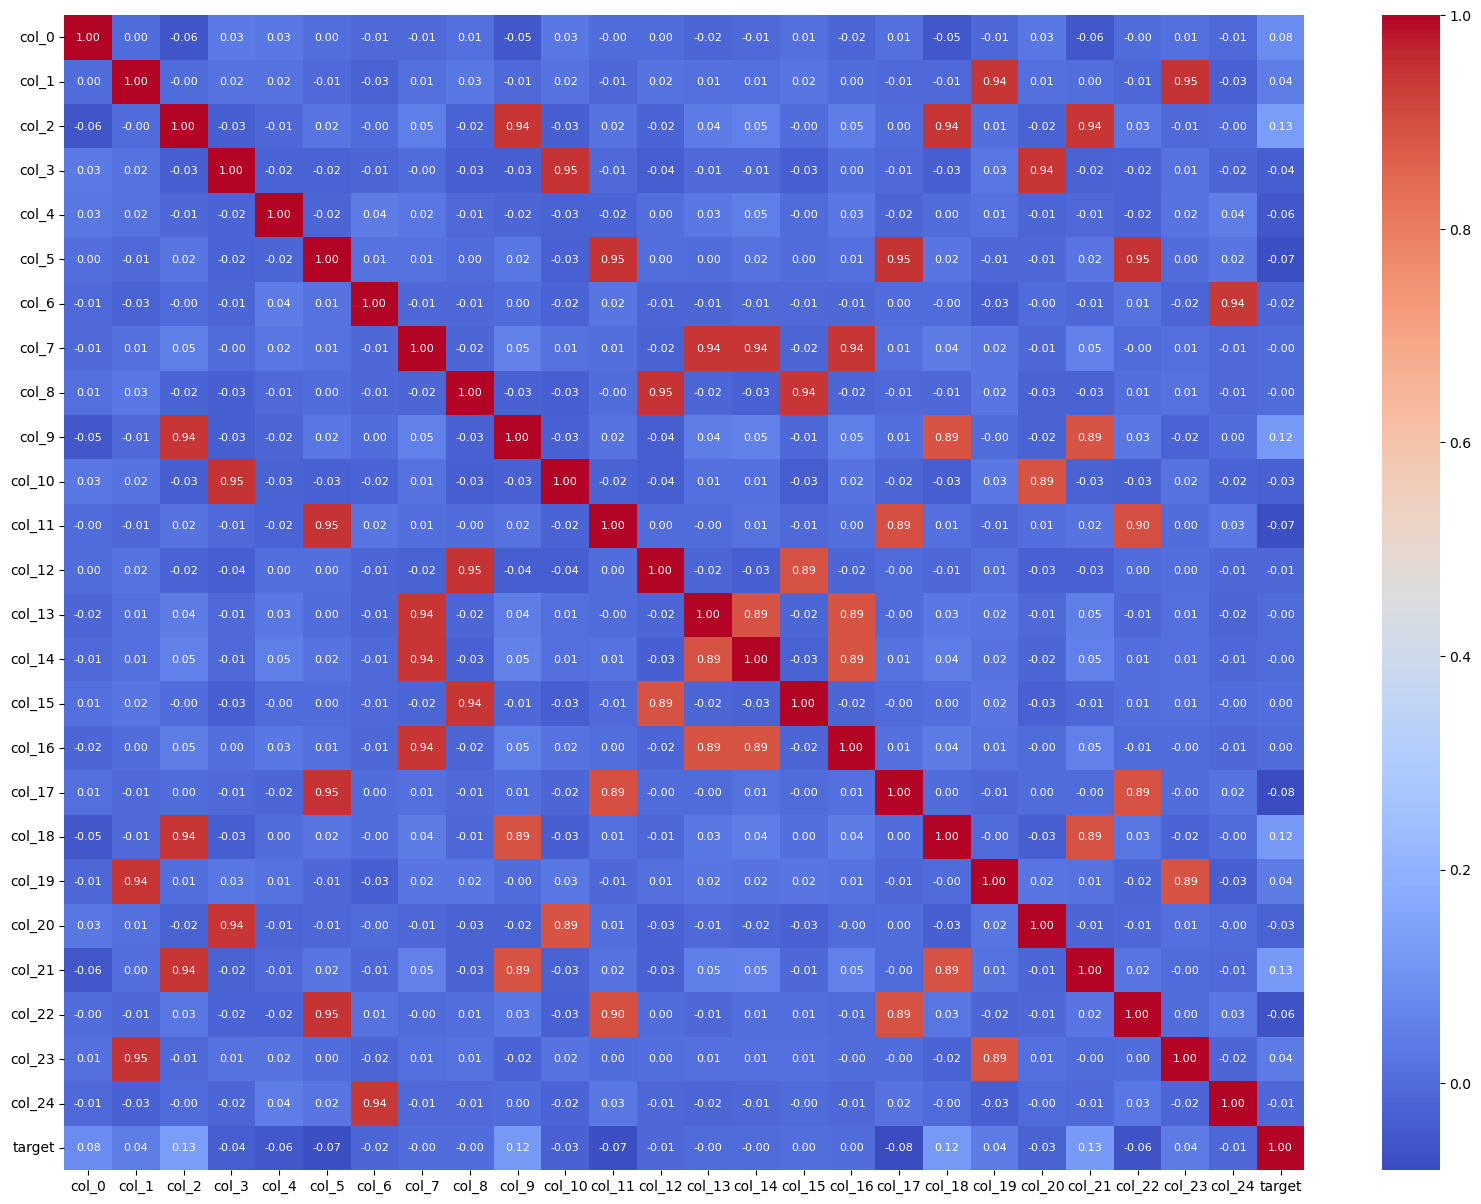

In [17]:
# Make the figure much larger (e.g., 20 inches by 15 inches)
plt.figure(figsize=(20, 15))

# Plot with 'annot=True' but a smaller font size
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm', annot_kws={"size": 8})
plt.show()

some features are veyr highly correlated and therefore need to be dropped.

C:\Users\kiera\AppData\Local\Temp\ipykernel_8768\2195007326.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')


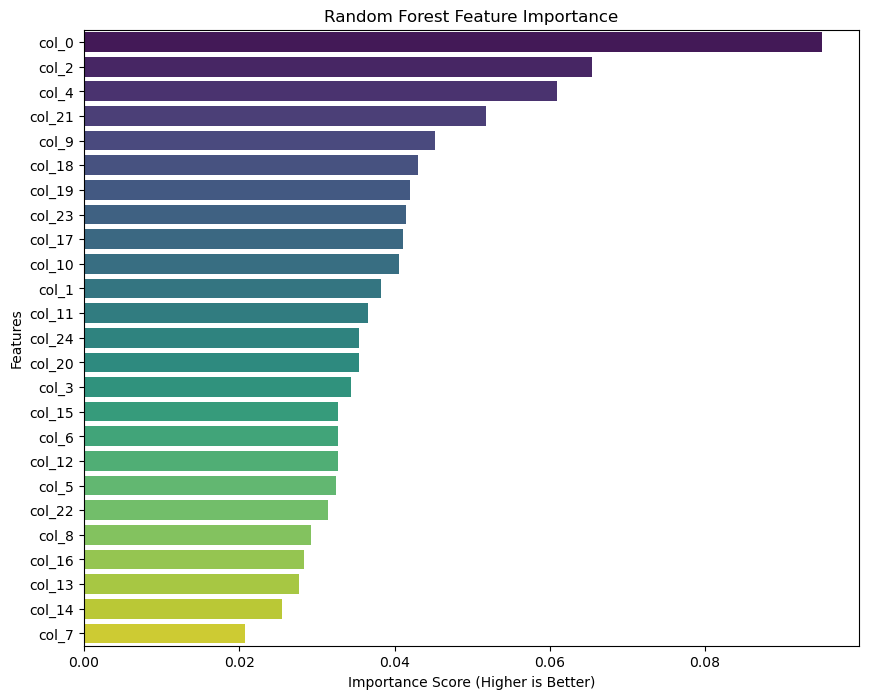

   feature  importance
0    col_0    0.095082
2    col_2    0.065457
4    col_4    0.060980
21  col_21    0.051719
9    col_9    0.045155
18  col_18    0.043002
19  col_19    0.041947
23  col_23    0.041440
17  col_17    0.041128
10  col_10    0.040553
1    col_1    0.038254
11  col_11    0.036600
24  col_24    0.035396
20  col_20    0.035381
3    col_3    0.034453
15  col_15    0.032770
6    col_6    0.032728
12  col_12    0.032673
5    col_5    0.032474
22  col_22    0.031383
8    col_8    0.029225
16  col_16    0.028284
13  col_13    0.027673
14  col_14    0.025551
7    col_7    0.020692


In [19]:
# 1. Prepare your data (Assuming your dataframe is named 'df')
X = df.drop(columns=['target'])
y = df['target']

# 2. Initialize and fit the model
# We use a large number of trees (n_estimators) for stable importance scores
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X, y)

# 3. Extract importance scores
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

# 4. Visualize the results
plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score (Higher is Better)')
plt.ylabel('Features')
plt.show()

# 5. Print the scores for your specific groups
print(feature_importance)

In [20]:
# 1. Initialize the "Judge" model
estimator = RandomForestRegressor(n_estimators=50, random_state=42)

# 2. Run RFECV
# min_features_to_select=1 ensures it tries every combination
# step=1 removes one feature at a time
selector = RFECV(estimator, step=1, cv=5, scoring='neg_mean_squared_error')
selector = selector.fit(X, y)

# 3. See the results
print(f"Optimal number of features: {selector.n_features_}")

# 4. Get the list of features to keep
keep_columns = X.columns[selector.support_]
print(f"Features to keep: {list(keep_columns)}")

Optimal number of features: 21
Features to keep: ['col_0', 'col_1', 'col_2', 'col_3', 'col_4', 'col_5', 'col_6', 'col_9', 'col_10', 'col_11', 'col_12', 'col_13', 'col_15', 'col_16', 'col_17', 'col_18', 'col_19', 'col_20', 'col_21', 'col_23', 'col_24']


In [41]:
def feature_analysis(col, n_bins=4):
    df[f'{col}_cut'] = pd.qcut(df[col], n_bins)
    display(df.groupby([f"{col}_cut"], as_index=False, observed=True)['target'].mean())

    temp_df = df.groupby(f"{col}_cut", observed=True)['target'].agg(['mean', 'median', 'std', 'count', 'min', 'max'])

    temp_df['noise_ratio'] = temp_df['std'] / temp_df['mean']
    display(temp_df)

    plt.figure(figsize=(12, 6))    
    ax = sns.barplot(
        data=df, 
        x=f'{col}_cut', 
        y='target', 
        palette='RdBu_r', 
        hue=f'{col}_cut',
        legend=False,
        errorbar=('ci', 95) # Adds 95% confidence intervals
    )
    
    global_mean = df['target'].mean()
    plt.axhline(global_mean, color='red', linestyle='--', alpha=0.6, label=f'Global Avg ({global_mean:.3f})')
    
    plt.title(f'Target Distribution by {col} Quantiles ({n_bins} Bins)', fontsize=14)
    plt.xlabel(f'{col} Quantile Ranges')
    plt.ylabel('Mean Target')
    plt.xticks(rotation=30)
    plt.legend()
    plt.show()

# eda

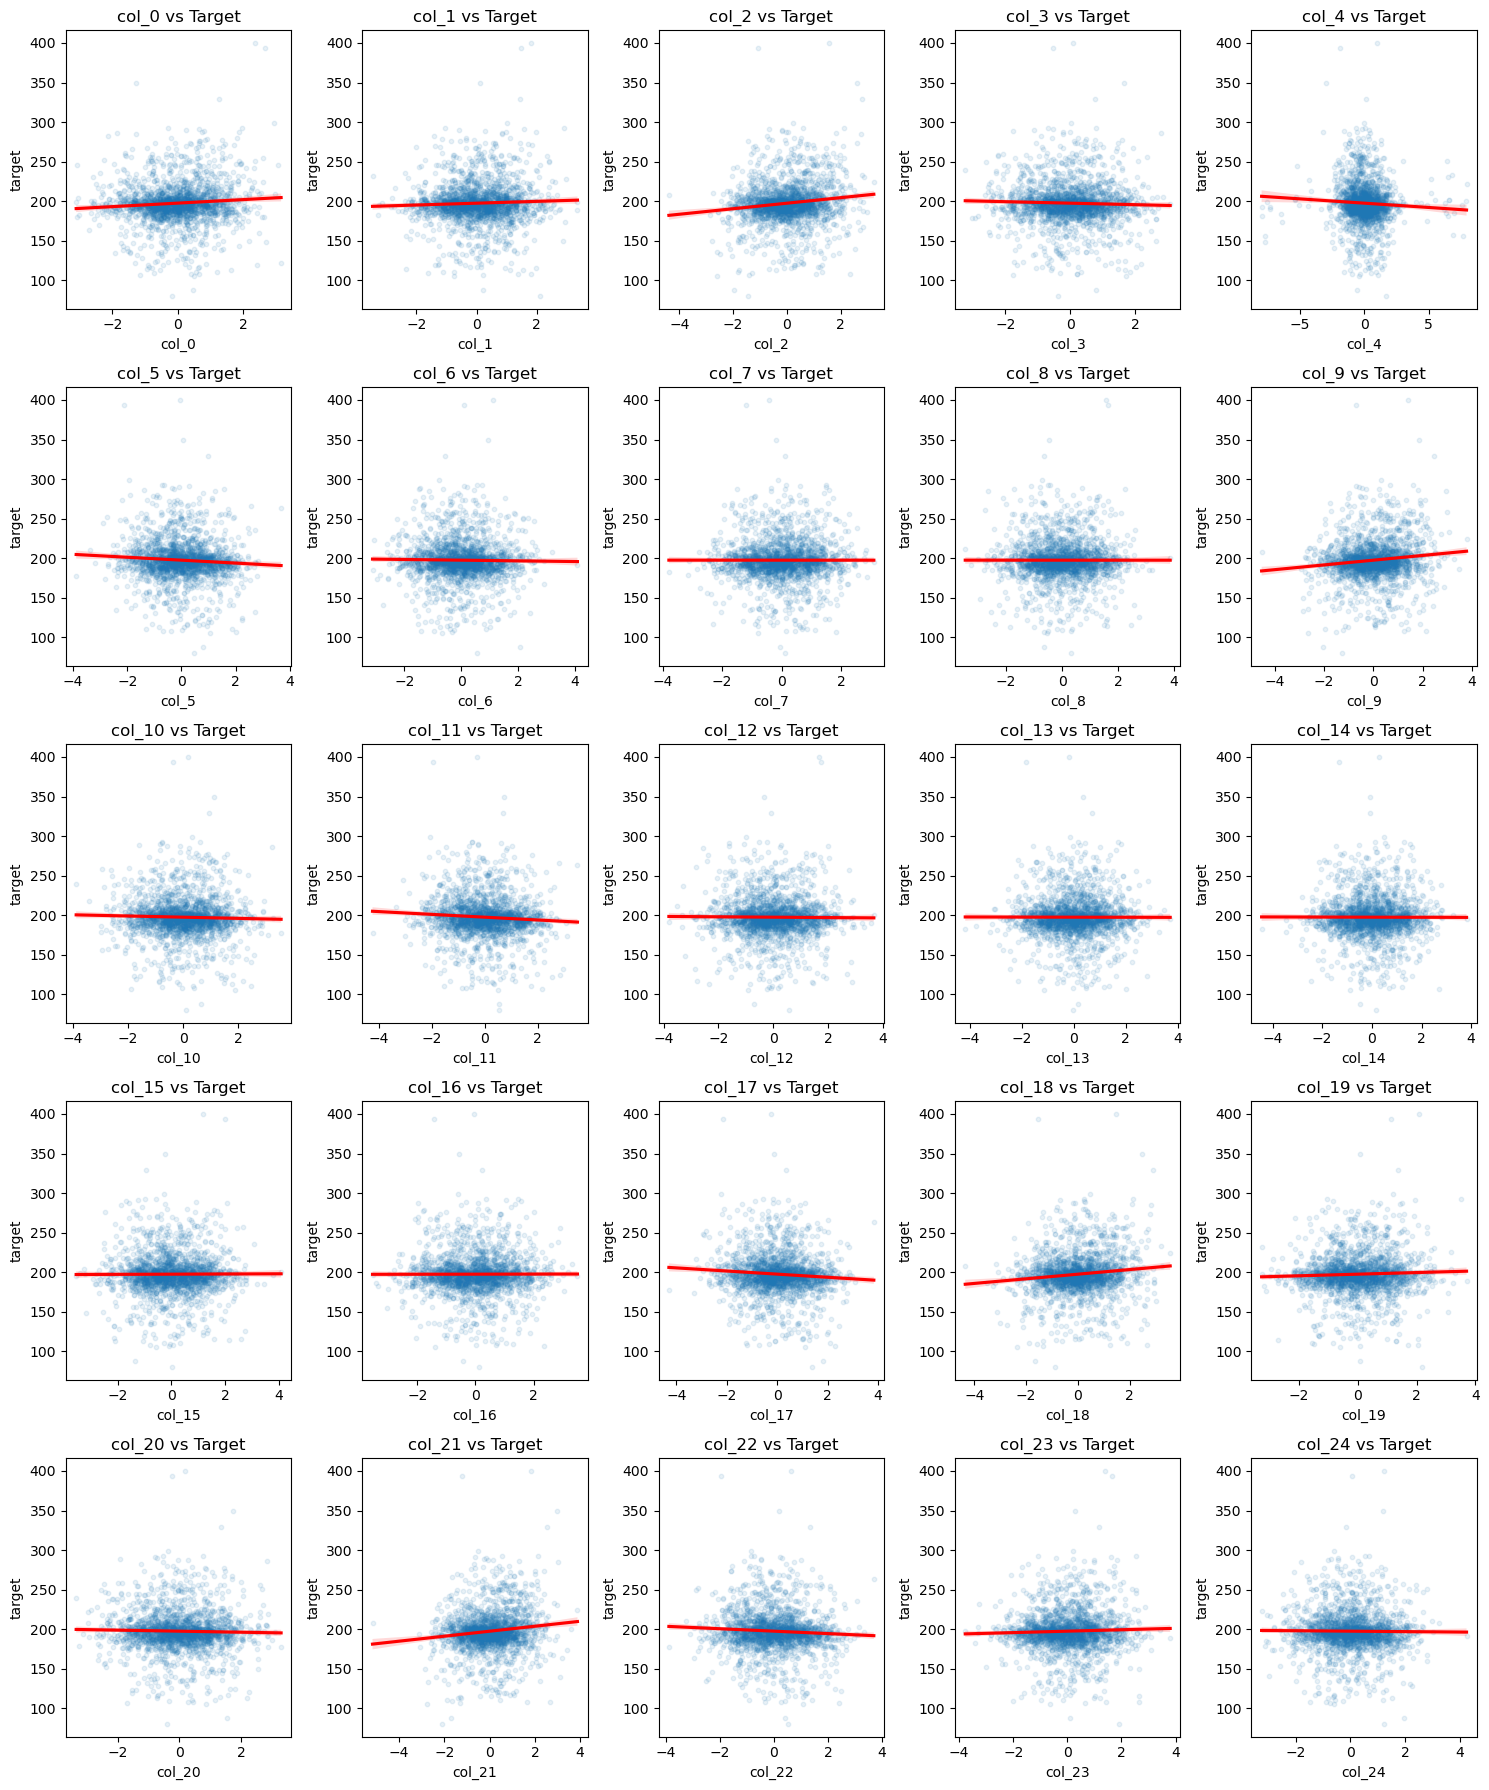

In [24]:
features = [col for col in df.columns if col.startswith('col_')]

# Create a grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=5, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(features):
    # sns.regplot adds a 'best fit' line automatically to help see linearity
    sns.regplot(x=df[col], y=df['target'], ax=axes[i], 
                scatter_kws={'alpha':0.1, 's':10}, # Make dots transparent to see density
                line_kws={'color':'red'})
    axes[i].set_title(f'{col} vs Target')

plt.tight_layout()
plt.show()

## col_0

,col_0_cut,target
0,"(-3.104, -0.911]",197.032004
1,"(-0.911, -0.44]",193.590917
2,"(-0.44, -0.0353]",196.367830
3,"(-0.0353, 0.366]",196.273385
4,"(0.366, 0.899]",197.513432
5,"(0.899, 3.158]",203.309808


,mean,median,std,count,min,max,noise_ratio
col_0_cut,,,,,,,
"(-3.104, -0.911]",197.032004,196.432153,25.741026,334,106.201614,349.973208,0.130644
"(-0.911, -0.44]",193.590917,193.711384,22.904177,332,108.665528,273.747141,0.118312
"(-0.44, -0.0353]",196.367830,195.422061,22.873927,334,80.000000,292.416417,0.116485
"(-0.0353, 0.366]",196.273385,196.265767,22.183635,332,116.253370,290.140708,0.113024
"(0.366, 0.899]",197.513432,196.539244,29.534727,333,87.691504,291.436374,0.149533
"(0.899, 3.158]",203.309808,197.719318,32.193218,334,110.494596,400.000000,0.158346


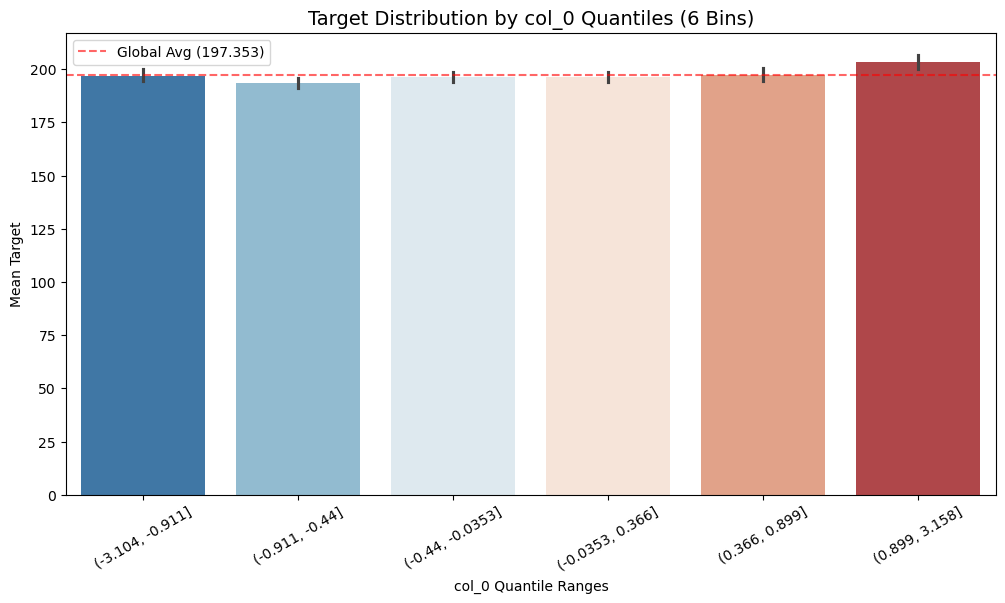

In [49]:
feature_analysis("col_0", 6)

In [38]:
df['col_0_high'] = (df['col_0'] > 0.612).astype(int)

In [32]:
df['log_col_0'] = np.log1p(df['col_0'] - df['col_0'].min())

,col_1_cut,target
0,"(-3.4539999999999997, -1.226]",194.049803
1,"(-1.226, -0.812]",198.346540
2,"(-0.812, -0.516]",196.263501
3,"(-0.516, -0.238]",197.224320
4,"(-0.238, 0.00393]",198.569654
5,"(0.00393, 0.271]",195.356509
6,"(0.271, 0.556]",196.493907
7,"(0.556, 0.883]",200.977254
8,"(0.883, 1.294]",194.811952
9,"(1.294, 3.349]",201.423049


,mean,median,std,count,min,max,noise_ratio
col_1_cut,,,,,,,
"(-3.4539999999999997, -1.226]",194.049803,194.461765,23.132515,200,108.665528,281.946756,0.119209
"(-1.226, -0.812]",198.346540,195.918676,21.474259,200,110.494596,292.860631,0.108266
"(-0.812, -0.516]",196.263501,195.818181,25.672599,200,105.263432,290.140708,0.130807
"(-0.516, -0.238]",197.224320,195.071139,21.469602,200,119.238166,280.140598,0.108859
"(-0.238, 0.00393]",198.569654,196.994836,24.123279,200,116.253370,277.314646,0.121485
"(0.00393, 0.271]",195.356509,194.034294,31.178827,199,87.691504,349.973208,0.159600
"(0.271, 0.556]",196.493907,194.623080,22.485531,200,122.386242,273.282951,0.114434
"(0.556, 0.883]",200.977254,197.309160,26.016010,200,135.682789,286.592472,0.129448
"(0.883, 1.294]",194.811952,196.088262,26.573701,200,112.641142,298.702722,0.136407


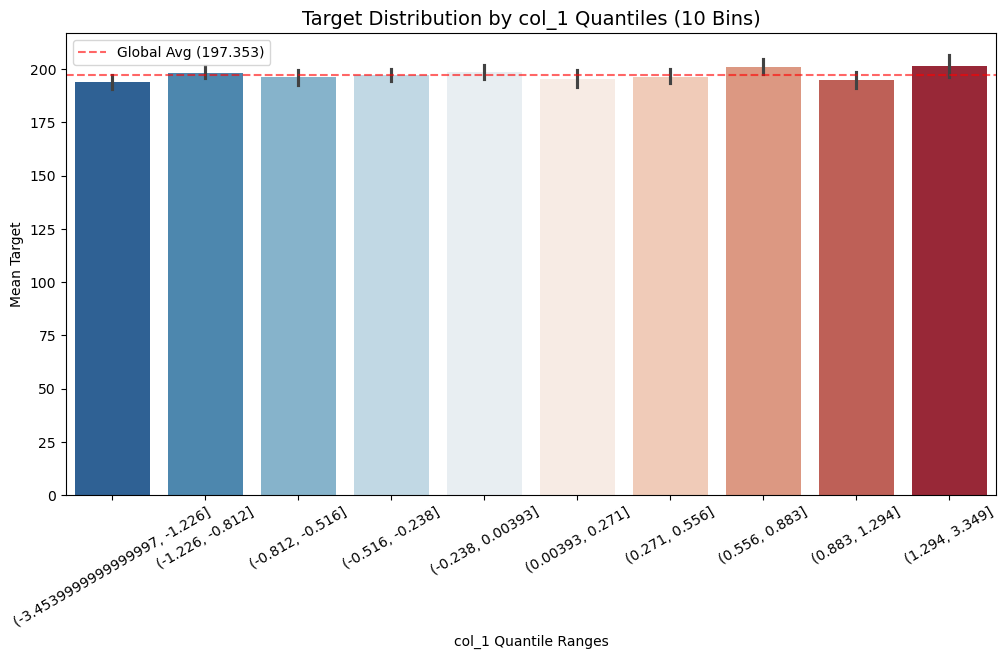

In [54]:
feature_analysis("col_1", 10)

,col_2_cut,target
0,"(-4.390000000000001, -1.223]",190.471141
1,"(-1.223, -0.804]",197.025131
2,"(-0.804, -0.511]",196.748429
3,"(-0.511, -0.238]",196.137357
4,"(-0.238, -0.00914]",194.979947
5,"(-0.00914, 0.23]",196.973569
6,"(0.23, 0.506]",198.760428
7,"(0.506, 0.82]",197.479511
8,"(0.82, 1.285]",199.393797
9,"(1.285, 3.226]",205.555265


,mean,median,std,count,min,max,noise_ratio
col_2_cut,,,,,,,
"(-4.390000000000001, -1.223]",190.471141,193.856939,29.180138,200,80.000000,276.022298,0.153200
"(-1.223, -0.804]",197.025131,194.337067,25.158943,200,133.615174,394.192258,0.127694
"(-0.804, -0.511]",196.748429,195.934892,21.493036,200,114.085108,291.436374,0.109241
"(-0.511, -0.238]",196.137357,193.490062,19.044568,200,112.641142,263.386549,0.097098
"(-0.238, -0.00914]",194.979947,193.745157,23.457477,200,115.777105,290.140708,0.120307
"(-0.00914, 0.23]",196.973569,195.936816,24.670838,199,114.736771,298.702722,0.125249
"(0.23, 0.506]",198.760428,197.480559,25.478740,200,116.253370,280.140598,0.128188
"(0.506, 0.82]",197.479511,196.131128,25.736612,200,120.154795,292.860631,0.130325
"(0.82, 1.285]",199.393797,197.449225,25.353598,200,108.366523,271.524131,0.127153


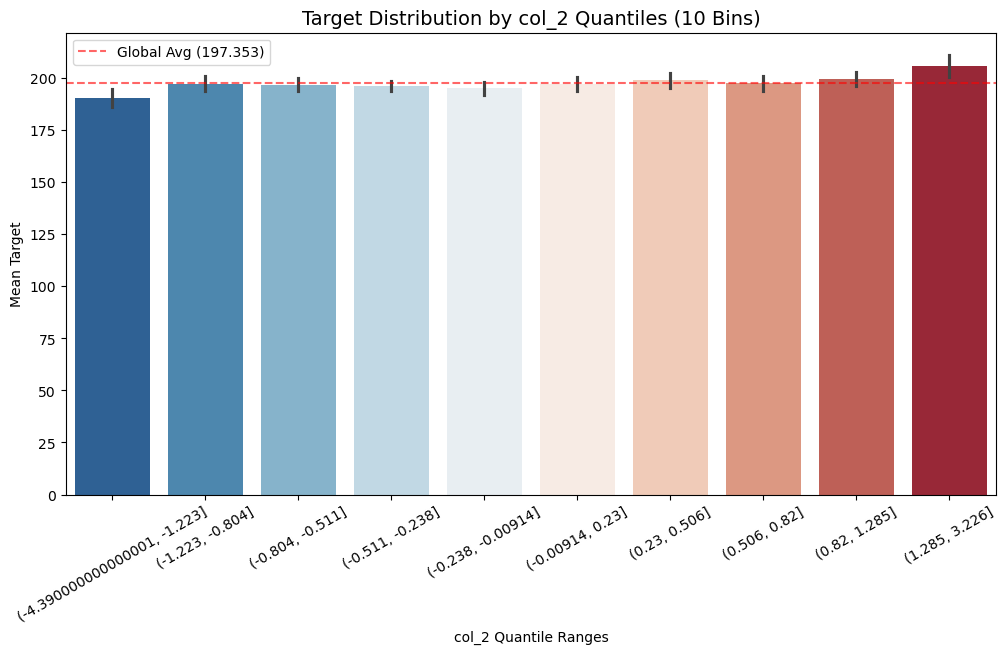

In [51]:
feature_analysis("col_2", 10)

,col_3_cut,target
0,"(-3.238, -1.294]",199.400540
1,"(-1.294, -0.817]",199.177121
2,"(-0.817, -0.513]",197.109013
3,"(-0.513, -0.245]",193.434586
4,"(-0.245, -0.00641]",197.435208
5,"(-0.00641, 0.252]",200.197780
6,"(0.252, 0.523]",198.617715
7,"(0.523, 0.811]",196.918785
8,"(0.811, 1.27]",196.085442
9,"(1.27, 3.081]",195.164508


,mean,median,std,count,min,max,noise_ratio
col_3_cut,,,,,,,
"(-3.238, -1.294]",199.400540,198.006724,25.894639,200,106.201614,288.510777,0.129862
"(-1.294, -0.817]",199.177121,196.848922,24.302975,200,114.736771,290.140708,0.122017
"(-0.817, -0.513]",197.109013,196.222032,29.262201,200,112.641142,394.192258,0.148457
"(-0.513, -0.245]",193.434586,195.017390,25.222977,200,80.000000,269.258083,0.130395
"(-0.245, -0.00641]",197.435208,195.576121,23.962722,200,120.659337,287.042407,0.121370
"(-0.00641, 0.252]",200.197780,196.508226,29.313802,199,107.483877,400.000000,0.146424
"(0.252, 0.523]",198.617715,195.905579,23.944403,200,110.494596,278.155918,0.120555
"(0.523, 0.811]",196.918785,194.431957,25.679934,200,87.691504,328.614535,0.130409
"(0.811, 1.27]",196.085442,195.128681,22.879398,200,119.238166,271.816445,0.116681


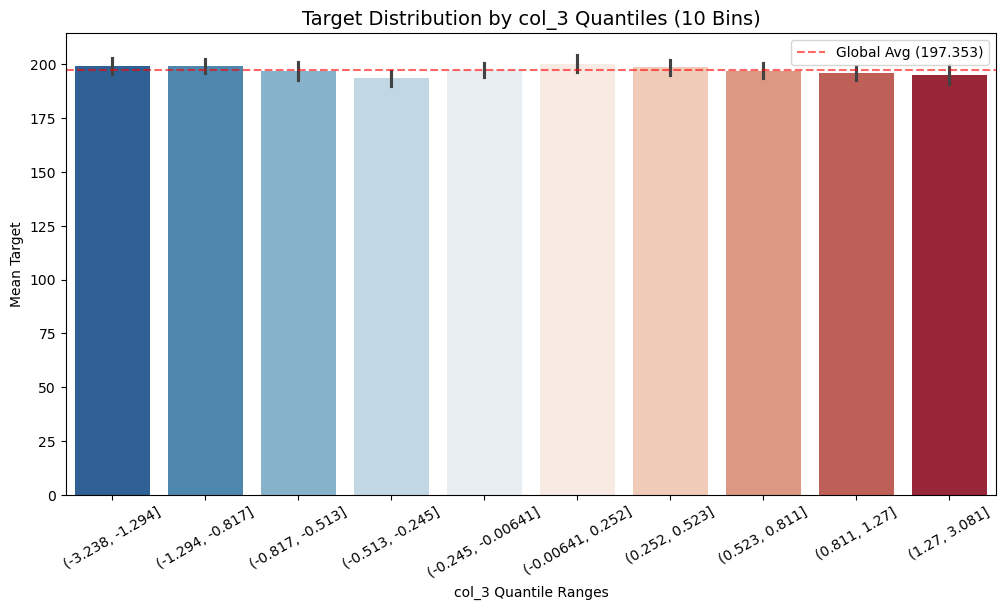

In [52]:
feature_analysis("col_3", 10)

,col_4_cut,target
0,"(-7.970000000000001, -1.321]",201.904229
1,"(-1.321, -0.841]",198.134928
2,"(-0.841, -0.533]",198.708850
3,"(-0.533, -0.263]",199.543107
4,"(-0.263, -0.0186]",199.416039
5,"(-0.0186, 0.231]",196.233592
6,"(0.231, 0.507]",194.710491
7,"(0.507, 0.879]",196.558563
8,"(0.879, 1.351]",194.870967
9,"(1.351, 7.941]",193.440110


,mean,median,std,count,min,max,noise_ratio
col_4_cut,,,,,,,
"(-7.970000000000001, -1.321]",201.904229,199.581207,30.951308,200,110.494596,394.192258,0.153297
"(-1.321, -0.841]",198.134928,194.550528,28.499313,200,108.366523,285.090376,0.143838
"(-0.841, -0.533]",198.708850,196.623590,25.650097,200,87.691504,292.416417,0.129084
"(-0.533, -0.263]",199.543107,197.228235,26.891846,200,105.263432,280.140598,0.134767
"(-0.263, -0.0186]",199.416039,196.957668,25.724746,200,131.361387,298.702722,0.129000
"(-0.0186, 0.231]",196.233592,195.542869,22.751487,199,112.734726,328.614535,0.115941
"(0.231, 0.507]",194.710491,193.489205,25.639622,200,114.736771,290.140708,0.131681
"(0.507, 0.879]",196.558563,195.584674,22.589000,200,108.665528,273.428468,0.114922
"(0.879, 1.351]",194.870967,193.670648,29.034684,200,106.201614,400.000000,0.148994


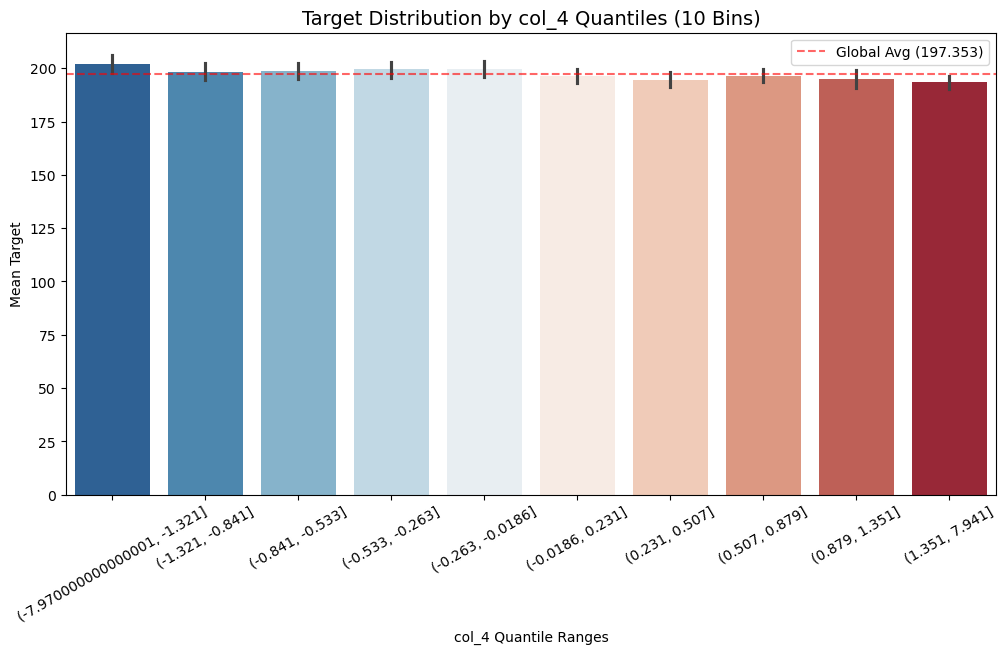

In [55]:
feature_analysis("col_4", 10)

,col_5_cut,target
0,"(-3.889, -1.302]",201.595932
1,"(-1.302, -0.832]",197.657055
2,"(-0.832, -0.512]",195.521836
3,"(-0.512, -0.273]",199.781049
4,"(-0.273, -0.0199]",200.019539
5,"(-0.0199, 0.239]",195.887324
6,"(0.239, 0.519]",197.803359
7,"(0.519, 0.869]",197.761034
8,"(0.869, 1.364]",193.828398
9,"(1.364, 3.683]",193.663617


,mean,median,std,count,min,max,noise_ratio
col_5_cut,,,,,,,
"(-3.889, -1.302]",201.595932,197.845258,28.616097,200,126.431347,394.192258,0.141948
"(-1.302, -0.832]",197.657055,195.752771,26.200843,200,110.494596,280.348135,0.132557
"(-0.832, -0.512]",195.521836,193.952131,24.154357,200,108.366523,292.860631,0.123538
"(-0.512, -0.273]",199.781049,198.367971,25.856149,200,107.483877,288.510777,0.129422
"(-0.273, -0.0199]",200.019539,197.057682,29.526070,200,120.659337,400.000000,0.147616
"(-0.0199, 0.239]",195.887324,195.359390,26.741169,199,108.665528,349.973208,0.136513
"(0.239, 0.519]",197.803359,194.445604,24.391794,200,80.000000,291.436374,0.123313
"(0.519, 0.869]",197.761034,196.975541,24.676187,200,87.691504,281.946756,0.124778
"(0.869, 1.364]",193.828398,193.588286,25.848259,200,105.263432,328.614535,0.133356


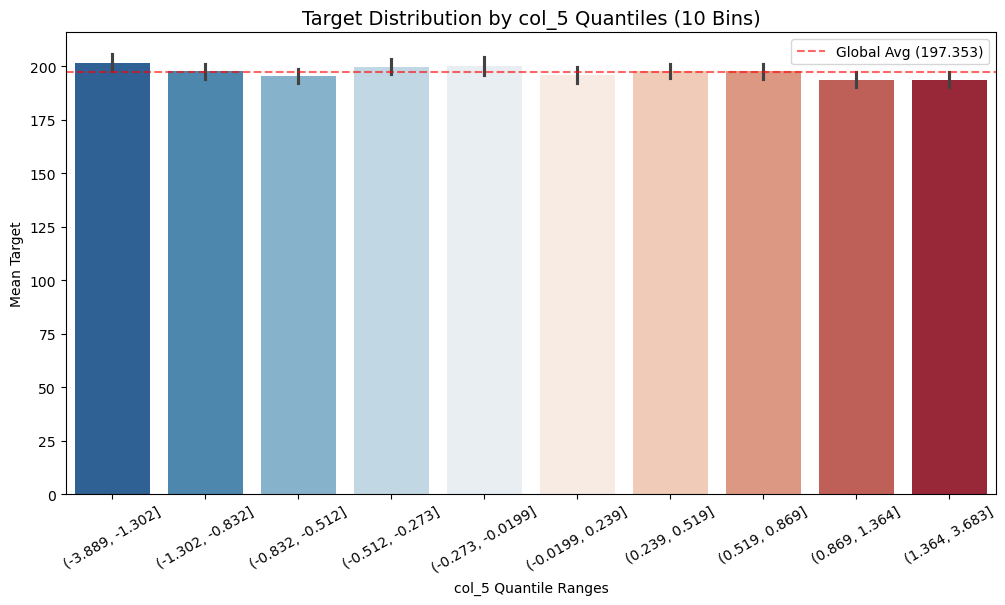

In [56]:
feature_analysis("col_5", 10)

,col_6_cut,target
0,"(-3.12, -1.207]",199.203415
1,"(-1.207, -0.812]",194.943576
2,"(-0.812, -0.465]",199.489379
3,"(-0.465, -0.237]",196.827675
4,"(-0.237, 0.0119]",197.199823
5,"(0.0119, 0.236]",197.512094
6,"(0.236, 0.491]",197.145560
7,"(0.491, 0.806]",199.739538
8,"(0.806, 1.291]",195.177696
9,"(1.291, 4.088]",196.288512


,mean,median,std,count,min,max,noise_ratio
col_6_cut,,,,,,,
"(-3.12, -1.207]",199.203415,196.232285,27.810598,200,108.366523,288.510777,0.139609
"(-1.207, -0.812]",194.943576,195.135778,24.077067,200,107.483877,285.090376,0.123508
"(-0.812, -0.465]",199.489379,196.868302,28.025324,200,105.263432,328.614535,0.140485
"(-0.465, -0.237]",196.827675,194.754272,28.078137,200,106.201614,280.348135,0.142653
"(-0.237, 0.0119]",197.199823,196.401578,24.298173,200,114.736771,281.946756,0.123216
"(0.0119, 0.236]",197.512094,194.830807,28.603897,199,121.630118,394.192258,0.144821
"(0.236, 0.491]",197.145560,196.090404,22.087832,200,119.573770,286.592472,0.112038
"(0.491, 0.806]",199.739538,197.441102,25.245647,200,80.000000,292.860631,0.126393
"(0.806, 1.291]",195.177696,192.926490,29.673041,200,110.857473,400.000000,0.152031


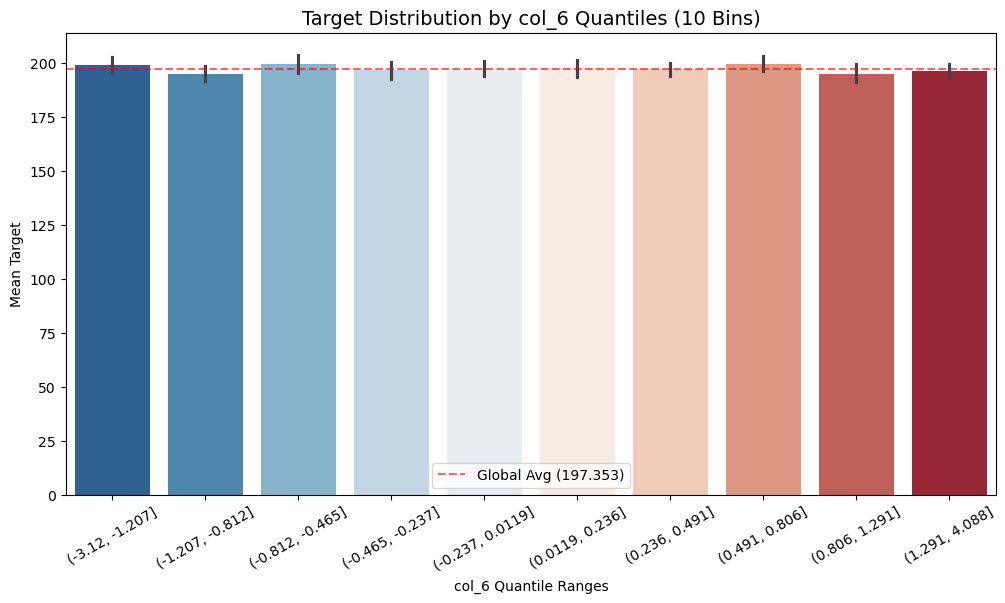

In [57]:
feature_analysis("col_6", 10)

,col_7_cut,target
0,"(-3.7929999999999997, -1.279]",198.200011
1,"(-1.279, -0.878]",200.788158
2,"(-0.878, -0.512]",194.224621
3,"(-0.512, -0.24]",196.533511
4,"(-0.24, 0.00814]",197.685943
5,"(0.00814, 0.248]",198.480494
6,"(0.248, 0.536]",195.207899
7,"(0.536, 0.873]",196.886114
8,"(0.873, 1.275]",196.237675
9,"(1.275, 3.098]",199.287684


,mean,median,std,count,min,max,noise_ratio
col_7_cut,,,,,,,
"(-3.7929999999999997, -1.279]",198.200011,195.726527,24.267626,200,116.293378,286.771919,0.122440
"(-1.279, -0.878]",200.788158,196.607101,27.304045,200,116.253370,394.192258,0.135984
"(-0.878, -0.512]",194.224621,195.355702,23.918093,200,105.263432,267.180221,0.123147
"(-0.512, -0.24]",196.533511,194.393242,28.561273,200,114.736771,400.000000,0.145325
"(-0.24, 0.00814]",197.685943,196.100340,26.049041,200,87.691504,349.973208,0.131770
"(0.00814, 0.248]",198.480494,195.585569,28.645372,199,80.000000,328.614535,0.144323
"(0.248, 0.536]",195.207899,195.235710,24.920063,200,107.483877,277.500687,0.127659
"(0.536, 0.873]",196.886114,195.583992,28.828742,200,110.494596,291.436374,0.146423
"(0.873, 1.275]",196.237675,196.224677,21.734424,200,108.665528,260.485223,0.110756


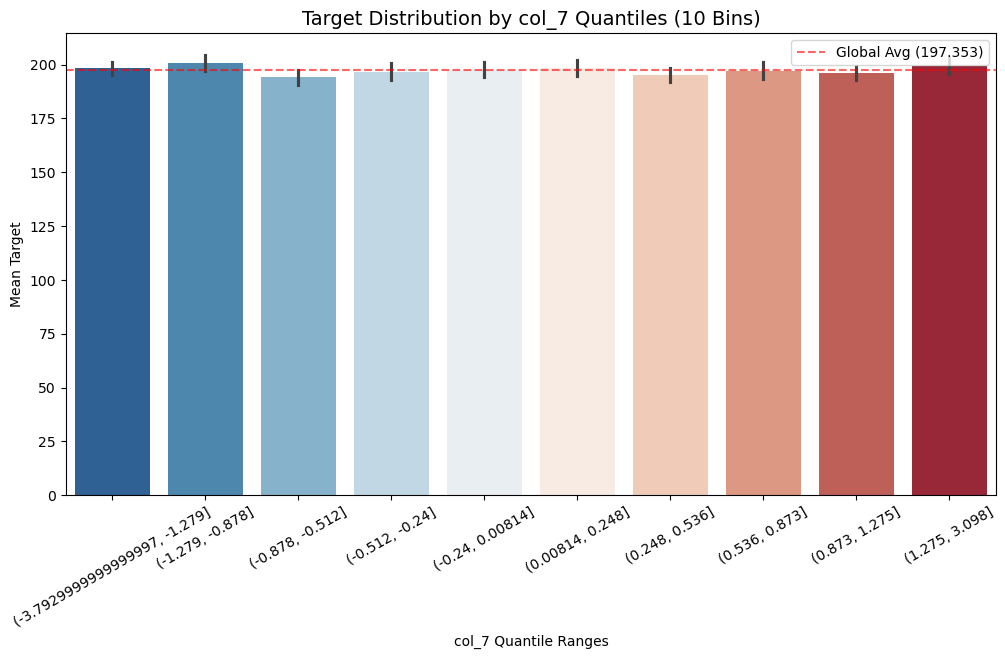

In [58]:
feature_analysis("col_7", 10)

,col_8_cut,target
0,"(-3.465, -1.259]",197.408372
1,"(-1.259, -0.856]",197.981362
2,"(-0.856, -0.543]",196.520981
3,"(-0.543, -0.297]",198.064400
4,"(-0.297, -0.0326]",197.155477
5,"(-0.0326, 0.261]",197.326177
6,"(0.261, 0.545]",195.389530
7,"(0.545, 0.879]",197.395082
8,"(0.879, 1.334]",199.506899
9,"(1.334, 3.868]",196.778058


,mean,median,std,count,min,max,noise_ratio
col_8_cut,,,,,,,
"(-3.465, -1.259]",197.408372,196.653544,27.778333,200,112.734726,286.771919,0.140715
"(-1.259, -0.856]",197.981362,196.108078,23.686248,200,112.641142,291.436374,0.119639
"(-0.856, -0.543]",196.520981,195.268748,30.283326,200,87.691504,328.614535,0.154097
"(-0.543, -0.297]",198.064400,196.042434,25.515990,200,107.483877,349.973208,0.128827
"(-0.297, -0.0326]",197.155477,195.039873,25.487834,200,110.494596,286.592472,0.129278
"(-0.0326, 0.261]",197.326177,195.891888,21.915614,199,108.665528,267.180221,0.111063
"(0.261, 0.545]",195.389530,195.681654,26.363855,200,80.000000,280.348135,0.134930
"(0.545, 0.879]",197.395082,196.745365,22.679901,200,116.293378,288.510777,0.114896
"(0.879, 1.334]",199.506899,195.850317,25.381387,200,130.614975,278.155918,0.127221


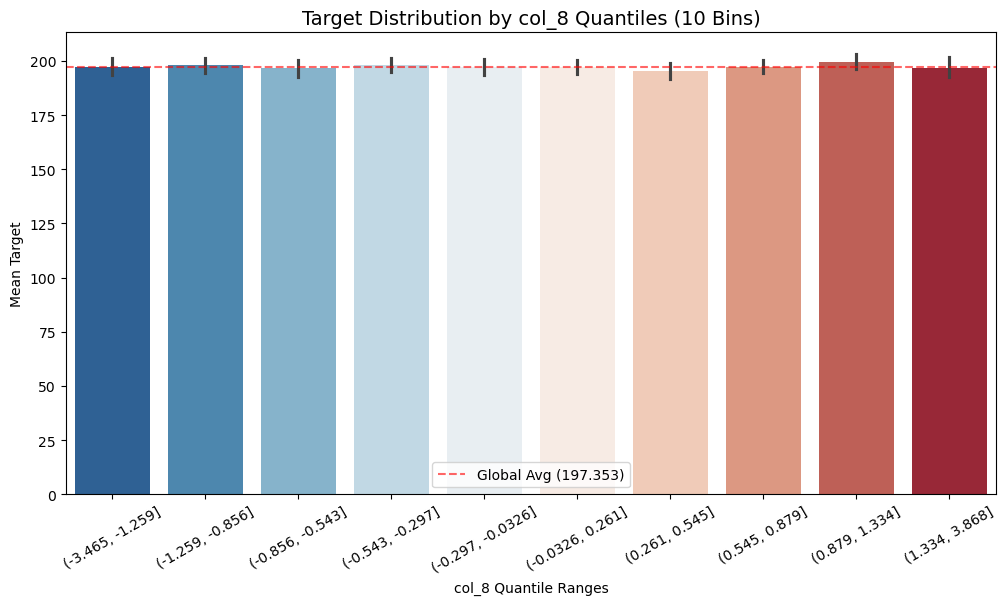

In [59]:
feature_analysis("col_8", 10)

,col_9_cut,target
0,"(-4.533, -1.3]",190.870836
1,"(-1.3, -0.843]",195.493104
2,"(-0.843, -0.551]",197.185216
3,"(-0.551, -0.273]",198.905592
4,"(-0.273, -0.00386]",195.778164
5,"(-0.00386, 0.267]",193.983970
6,"(0.267, 0.572]",198.563924
7,"(0.572, 0.857]",198.101279
8,"(0.857, 1.344]",198.821650
9,"(1.344, 3.787]",205.805891


,mean,median,std,count,min,max,noise_ratio
col_9_cut,,,,,,,
"(-4.533, -1.3]",190.870836,193.514311,25.753181,200,87.691504,269.258083,0.134925
"(-1.3, -0.843]",195.493104,194.542213,25.571483,200,80.000000,281.946756,0.130805
"(-0.843, -0.551]",197.185216,195.101034,24.150194,200,122.585263,394.192258,0.122475
"(-0.551, -0.273]",198.905592,196.419778,22.913048,200,127.813871,288.510777,0.115196
"(-0.273, -0.00386]",195.778164,196.196253,18.772770,200,123.608019,258.569741,0.095888
"(-0.00386, 0.267]",193.983970,194.305148,25.346435,199,112.641142,287.042407,0.130663
"(0.267, 0.572]",198.563924,196.484664,25.688019,200,119.569057,298.702722,0.129369
"(0.572, 0.857]",198.101279,196.035719,26.507132,200,126.431347,292.860631,0.133806
"(0.857, 1.344]",198.821650,197.339905,24.625329,200,108.366523,273.282951,0.123856


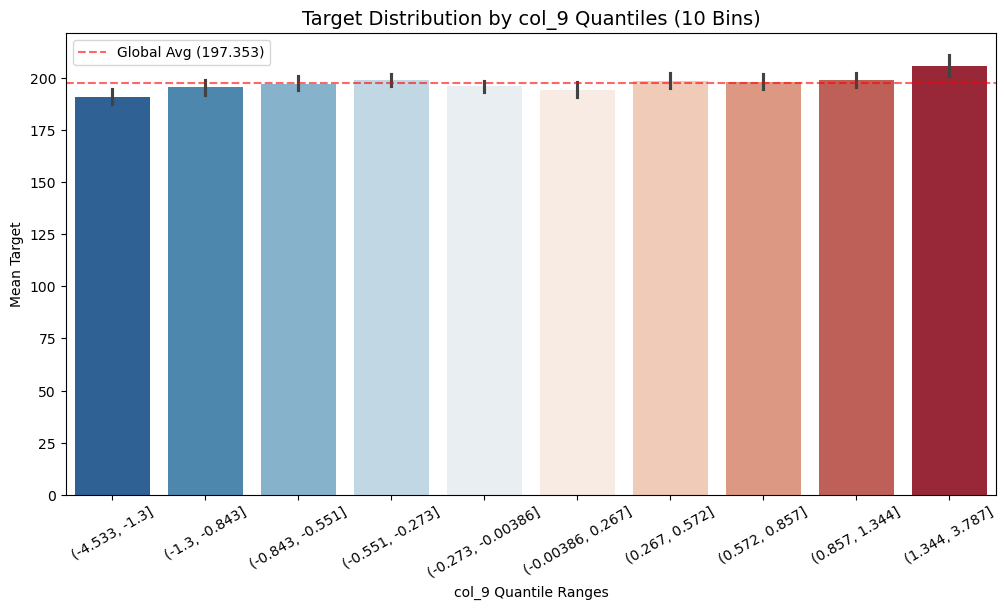

In [60]:
feature_analysis("col_9", 10)

,col_10_cut,target
0,"(-3.8729999999999998, -1.41]",197.990435
1,"(-1.41, -0.87]",198.995068
2,"(-0.87, -0.54]",197.542290
3,"(-0.54, -0.27]",196.979047
4,"(-0.27, 0.00869]",195.695693
5,"(0.00869, 0.259]",197.944612
6,"(0.259, 0.567]",197.161063
7,"(0.567, 0.897]",197.998052
8,"(0.897, 1.327]",200.628682
9,"(1.327, 3.551]",192.594489


,mean,median,std,count,min,max,noise_ratio
col_10_cut,,,,,,,
"(-3.8729999999999998, -1.41]",197.990435,197.762890,26.480035,200,106.201614,288.510777,0.133744
"(-1.41, -0.87]",198.995068,197.749596,21.933075,200,114.736771,273.282951,0.110219
"(-0.87, -0.54]",197.542290,196.249917,27.246221,200,108.665528,292.860631,0.137926
"(-0.54, -0.27]",196.979047,195.654829,26.938821,200,120.659337,394.192258,0.136760
"(-0.27, 0.00869]",195.695693,194.130161,25.618674,200,107.483877,286.771919,0.130911
"(0.00869, 0.259]",197.944612,195.886909,26.960763,199,80.000000,400.000000,0.136204
"(0.259, 0.567]",197.161063,195.151263,25.102166,200,108.366523,298.702722,0.127318
"(0.567, 0.897]",197.998052,196.079004,26.279616,200,87.691504,292.416417,0.132727
"(0.897, 1.327]",200.628682,195.652888,26.756034,200,126.431347,349.973208,0.133361


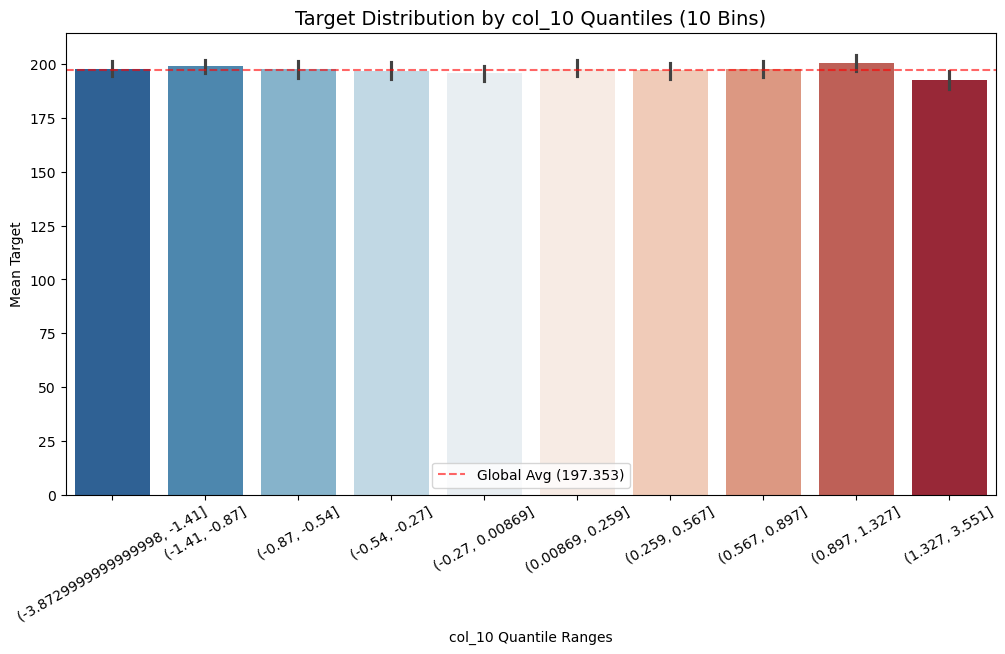

In [61]:
feature_analysis("col_10", 10)

,col_11_cut,target
0,"(-4.25, -1.406]",201.526462
1,"(-1.406, -0.912]",197.251602
2,"(-0.912, -0.577]",200.966792
3,"(-0.577, -0.284]",196.695339
4,"(-0.284, -0.0129]",197.991112
5,"(-0.0129, 0.269]",197.154270
6,"(0.269, 0.542]",194.456961
7,"(0.542, 0.911]",199.750627
8,"(0.911, 1.403]",194.023162
9,"(1.403, 3.513]",193.709152


,mean,median,std,count,min,max,noise_ratio
col_11_cut,,,,,,,
"(-4.25, -1.406]",201.526462,199.504861,29.990865,200,110.494596,394.192258,0.148818
"(-1.406, -0.912]",197.251602,195.064107,23.042878,200,116.866950,278.155918,0.116820
"(-0.912, -0.577]",200.966792,197.112672,26.404720,200,107.483877,286.771919,0.131388
"(-0.577, -0.284]",196.695339,195.478395,29.778013,200,108.665528,400.000000,0.151392
"(-0.284, -0.0129]",197.991112,195.403916,25.099416,200,116.293378,290.140708,0.126770
"(-0.0129, 0.269]",197.154270,195.075695,23.611974,199,115.777105,266.646439,0.119764
"(0.269, 0.542]",194.456961,195.929086,24.662214,200,87.691504,267.689598,0.126826
"(0.542, 0.911]",199.750627,196.655657,30.435124,200,80.000000,349.973208,0.152366
"(0.911, 1.403]",194.023162,194.398791,22.285202,200,116.253370,287.042407,0.114858


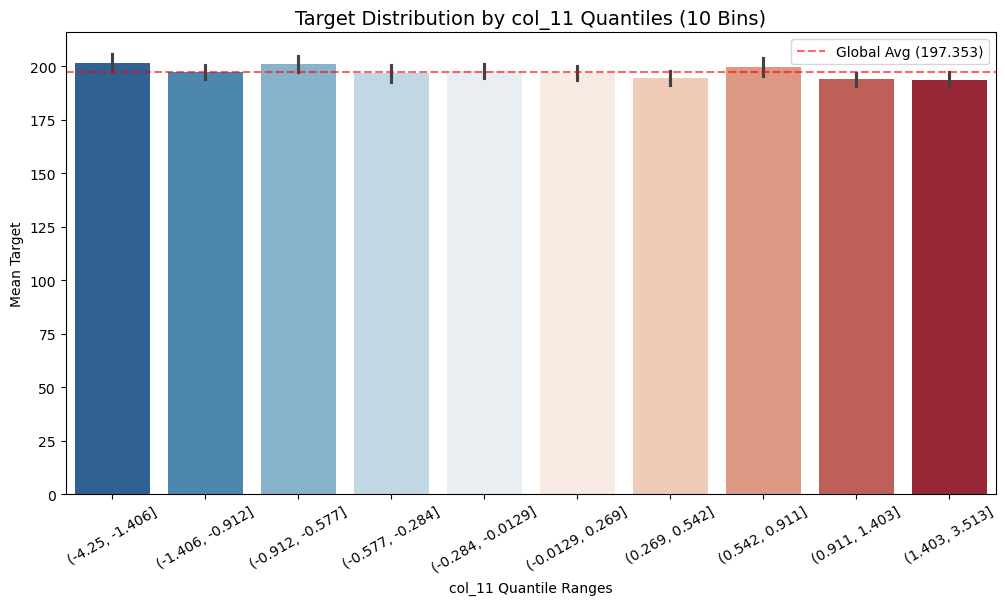

In [62]:
feature_analysis("col_11", 10)

,col_12_cut,target
0,"(-3.8049999999999997, -1.35]",199.316901
1,"(-1.35, -0.879]",197.894193
2,"(-0.879, -0.561]",197.973319
3,"(-0.561, -0.312]",196.915158
4,"(-0.312, -0.0208]",195.795677
5,"(-0.0208, 0.247]",197.239715
6,"(0.247, 0.563]",195.972750
7,"(0.563, 0.943]",195.755210
8,"(0.943, 1.439]",198.478508
9,"(1.439, 3.671]",198.184474


,mean,median,std,count,min,max,noise_ratio
col_12_cut,,,,,,,
"(-3.8049999999999997, -1.35]",199.316901,197.154215,29.649757,200,112.734726,291.436374,0.148757
"(-1.35, -0.879]",197.894193,197.575935,24.370682,200,105.263432,298.702722,0.123150
"(-0.879, -0.561]",197.973319,195.813598,23.378576,200,87.691504,281.946756,0.118090
"(-0.561, -0.312]",196.915158,195.003432,26.731165,200,119.238166,349.973208,0.135750
"(-0.312, -0.0208]",195.795677,194.347883,27.610615,200,106.201614,328.614535,0.141017
"(-0.0208, 0.247]",197.239715,196.743352,25.532389,199,108.366523,286.592472,0.129449
"(0.247, 0.563]",195.972750,194.456275,23.904758,200,122.585263,288.510777,0.121980
"(0.563, 0.943]",195.755210,195.276229,23.624602,200,80.000000,263.386549,0.120684
"(0.943, 1.439]",198.478508,197.032413,25.250118,200,114.085108,278.155918,0.127218


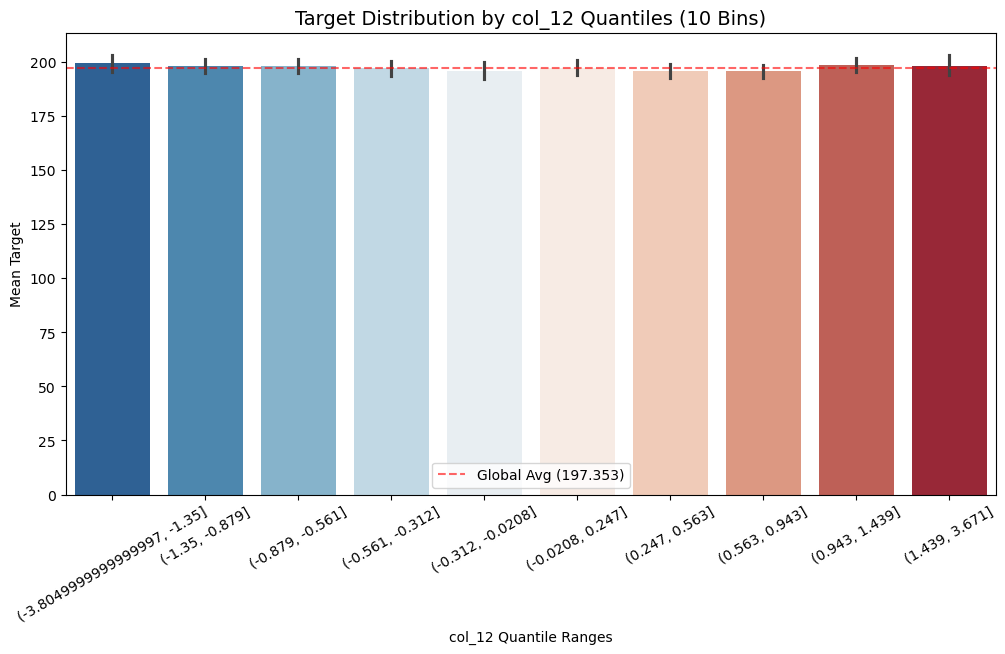

In [63]:
feature_analysis("col_12", 10)

,col_13_cut,target
0,"(-4.182, -1.395]",198.519840
1,"(-1.395, -0.935]",196.320762
2,"(-0.935, -0.571]",196.888795
3,"(-0.571, -0.259]",198.588542
4,"(-0.259, 0.00496]",196.823107
5,"(0.00496, 0.277]",196.019048
6,"(0.277, 0.547]",198.437874
7,"(0.547, 0.903]",198.802663
8,"(0.903, 1.354]",196.160437
9,"(1.354, 3.717]",196.958735


,mean,median,std,count,min,max,noise_ratio
col_13_cut,,,,,,,
"(-4.182, -1.395]",198.519840,195.971239,27.518509,200,116.293378,394.192258,0.138618
"(-1.395, -0.935]",196.320762,194.153154,21.819398,200,105.263432,285.090376,0.111142
"(-0.935, -0.571]",196.888795,195.475840,23.698267,200,114.085108,278.155918,0.120364
"(-0.571, -0.259]",198.588542,196.543227,24.059457,200,114.736771,277.314646,0.121152
"(-0.259, 0.00496]",196.823107,194.532076,31.076824,200,80.000000,400.000000,0.157892
"(0.00496, 0.277]",196.019048,194.566616,27.971749,199,87.691504,292.860631,0.142699
"(0.277, 0.547]",198.437874,196.226396,28.300246,200,107.483877,349.973208,0.142615
"(0.547, 0.903]",198.802663,197.264716,27.307994,200,112.734726,328.614535,0.137362
"(0.903, 1.354]",196.160437,195.934892,24.333336,200,108.665528,286.592472,0.124048


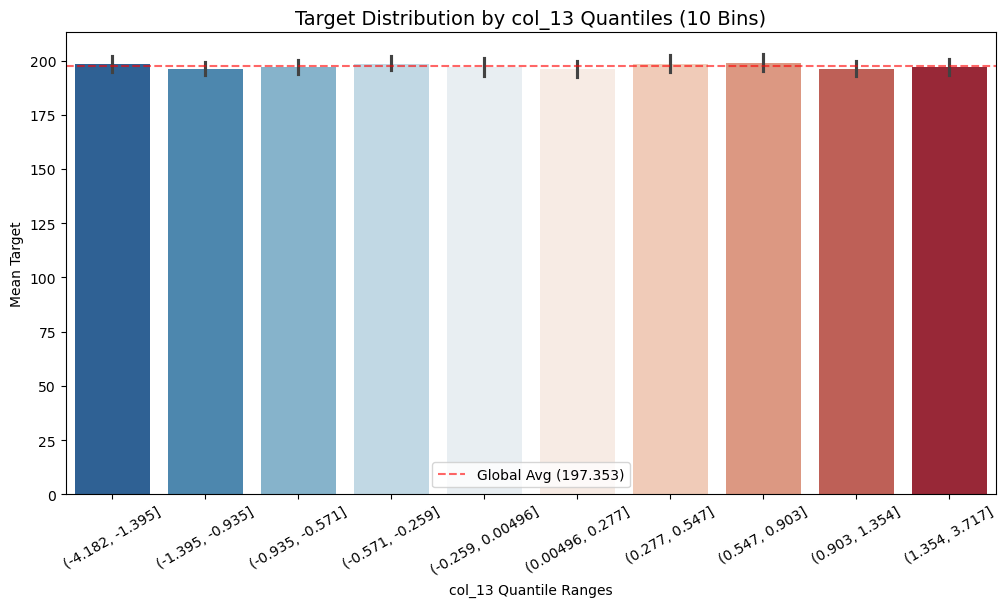

In [64]:
feature_analysis("col_13", 10)

,col_13_cut,target
0,"(-4.182, -1.395]",198.519840
1,"(-1.395, -0.935]",196.320762
2,"(-0.935, -0.571]",196.888795
3,"(-0.571, -0.259]",198.588542
4,"(-0.259, 0.00496]",196.823107
5,"(0.00496, 0.277]",196.019048
6,"(0.277, 0.547]",198.437874
7,"(0.547, 0.903]",198.802663
8,"(0.903, 1.354]",196.160437
9,"(1.354, 3.717]",196.958735


,mean,median,std,count,min,max,noise_ratio
col_13_cut,,,,,,,
"(-4.182, -1.395]",198.519840,195.971239,27.518509,200,116.293378,394.192258,0.138618
"(-1.395, -0.935]",196.320762,194.153154,21.819398,200,105.263432,285.090376,0.111142
"(-0.935, -0.571]",196.888795,195.475840,23.698267,200,114.085108,278.155918,0.120364
"(-0.571, -0.259]",198.588542,196.543227,24.059457,200,114.736771,277.314646,0.121152
"(-0.259, 0.00496]",196.823107,194.532076,31.076824,200,80.000000,400.000000,0.157892
"(0.00496, 0.277]",196.019048,194.566616,27.971749,199,87.691504,292.860631,0.142699
"(0.277, 0.547]",198.437874,196.226396,28.300246,200,107.483877,349.973208,0.142615
"(0.547, 0.903]",198.802663,197.264716,27.307994,200,112.734726,328.614535,0.137362
"(0.903, 1.354]",196.160437,195.934892,24.333336,200,108.665528,286.592472,0.124048


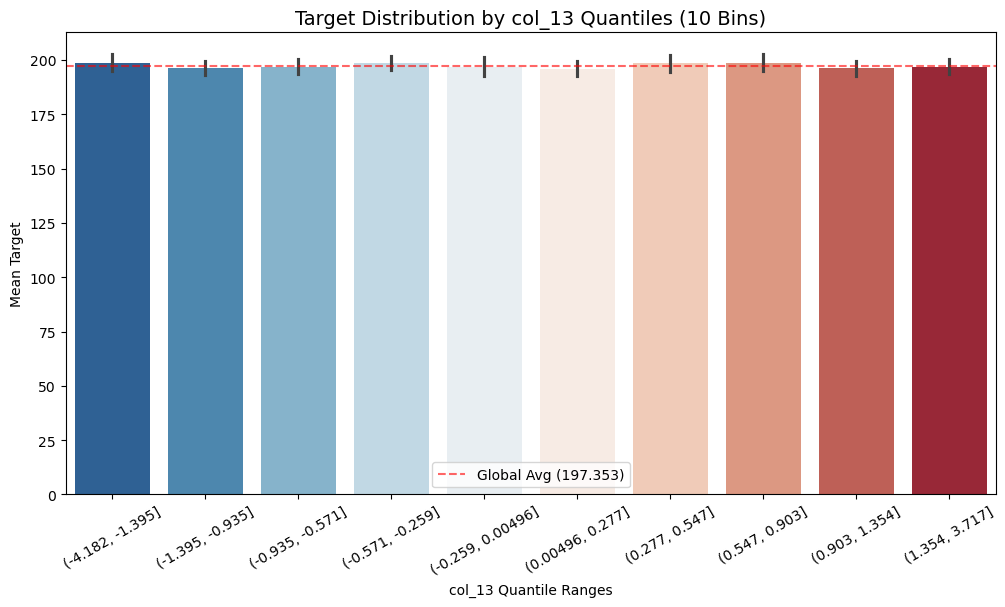

In [65]:
feature_analysis("col_13", 10)

,col_14_cut,target
0,"(-4.442, -1.382]",197.813457
1,"(-1.382, -0.897]",198.148868
2,"(-0.897, -0.535]",198.006504
3,"(-0.535, -0.272]",196.084745
4,"(-0.272, 0.00912]",198.075887
5,"(0.00912, 0.252]",198.751545
6,"(0.252, 0.536]",195.539439
7,"(0.536, 0.908]",193.903330
8,"(0.908, 1.384]",198.022937
9,"(1.384, 3.814]",199.186754


,mean,median,std,count,min,max,noise_ratio
col_14_cut,,,,,,,
"(-4.442, -1.382]",197.813457,195.311910,24.642325,200,116.293378,286.771919,0.124574
"(-1.382, -0.897]",198.148868,194.490425,26.485956,200,134.520526,394.192258,0.133667
"(-0.897, -0.535]",198.006504,196.817411,23.793035,200,105.263432,277.500687,0.120163
"(-0.535, -0.272]",196.084745,195.882734,26.524700,200,87.691504,288.510777,0.135272
"(-0.272, 0.00912]",198.075887,196.501358,28.042273,200,112.734726,349.973208,0.141573
"(0.00912, 0.252]",198.751545,197.241928,27.924795,199,80.000000,292.860631,0.140501
"(0.252, 0.536]",195.539439,194.061497,28.680158,200,110.857473,400.000000,0.146672
"(0.536, 0.908]",193.903330,193.795493,25.141064,200,107.483877,287.042407,0.129658
"(0.908, 1.384]",198.022937,195.974135,26.171900,200,108.665528,292.416417,0.132166


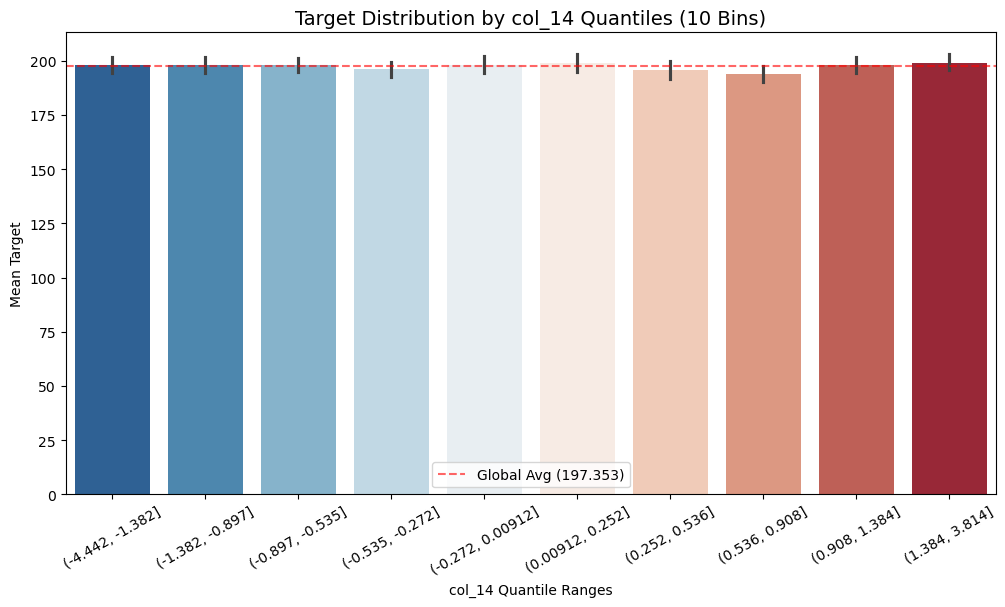

In [67]:
feature_analysis("col_14", 10)

,col_15_cut,target
0,"(-3.56, -1.315]",196.993776
1,"(-1.315, -0.917]",198.645554
2,"(-0.917, -0.566]",194.075815
3,"(-0.566, -0.284]",200.361234
4,"(-0.284, -0.0166]",199.181086
5,"(-0.0166, 0.292]",194.539976
6,"(0.292, 0.581]",196.549213
7,"(0.581, 0.953]",196.886093
8,"(0.953, 1.397]",197.430830
9,"(1.397, 4.094]",198.848830


,mean,median,std,count,min,max,noise_ratio
col_15_cut,,,,,,,
"(-3.56, -1.315]",196.993776,196.571340,29.361707,200,87.691504,290.140708,0.149049
"(-1.315, -0.917]",198.645554,196.626847,27.065265,200,112.641142,328.614535,0.136249
"(-0.917, -0.566]",194.075815,194.246205,25.482387,200,105.263432,292.416417,0.131301
"(-0.566, -0.284]",200.361234,195.612656,22.943676,200,149.427524,298.702722,0.114512
"(-0.284, -0.0166]",199.181086,196.428682,27.534825,200,106.201614,349.973208,0.138240
"(-0.0166, 0.292]",194.539976,196.519598,24.242322,199,80.000000,269.868732,0.124614
"(0.292, 0.581]",196.549213,195.198842,22.595746,200,110.857473,261.368534,0.114962
"(0.581, 0.953]",196.886093,194.794199,25.885218,200,127.813871,288.510777,0.131473
"(0.953, 1.397]",197.430830,195.154433,27.537597,200,120.154795,400.000000,0.139480


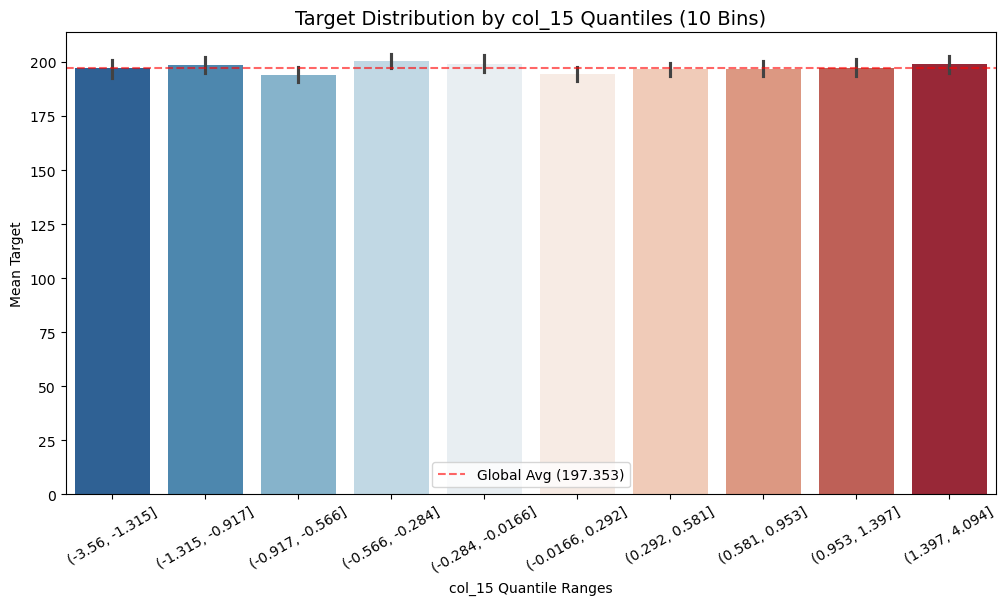

In [68]:
feature_analysis("col_15", 10)

,col_15_cut,target
0,"(-3.56, -1.315]",196.993776
1,"(-1.315, -0.917]",198.645554
2,"(-0.917, -0.566]",194.075815
3,"(-0.566, -0.284]",200.361234
4,"(-0.284, -0.0166]",199.181086
5,"(-0.0166, 0.292]",194.539976
6,"(0.292, 0.581]",196.549213
7,"(0.581, 0.953]",196.886093
8,"(0.953, 1.397]",197.430830
9,"(1.397, 4.094]",198.848830


,mean,median,std,count,min,max,noise_ratio
col_15_cut,,,,,,,
"(-3.56, -1.315]",196.993776,196.571340,29.361707,200,87.691504,290.140708,0.149049
"(-1.315, -0.917]",198.645554,196.626847,27.065265,200,112.641142,328.614535,0.136249
"(-0.917, -0.566]",194.075815,194.246205,25.482387,200,105.263432,292.416417,0.131301
"(-0.566, -0.284]",200.361234,195.612656,22.943676,200,149.427524,298.702722,0.114512
"(-0.284, -0.0166]",199.181086,196.428682,27.534825,200,106.201614,349.973208,0.138240
"(-0.0166, 0.292]",194.539976,196.519598,24.242322,199,80.000000,269.868732,0.124614
"(0.292, 0.581]",196.549213,195.198842,22.595746,200,110.857473,261.368534,0.114962
"(0.581, 0.953]",196.886093,194.794199,25.885218,200,127.813871,288.510777,0.131473
"(0.953, 1.397]",197.430830,195.154433,27.537597,200,120.154795,400.000000,0.139480


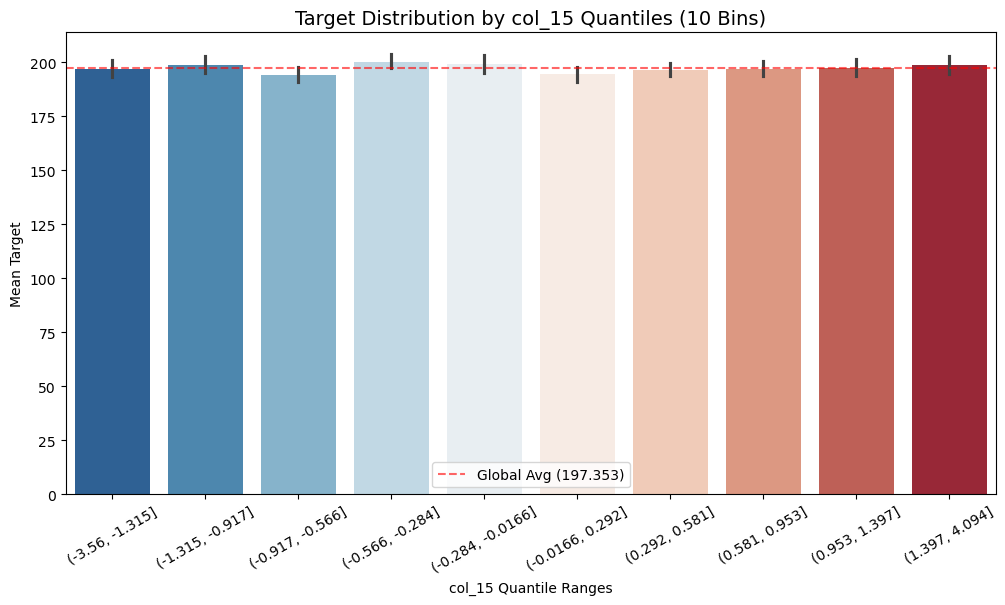

In [69]:
feature_analysis("col_15", 10)

,col_16_cut,target
0,"(-3.541, -1.409]",199.040804
1,"(-1.409, -0.924]",197.773334
2,"(-0.924, -0.576]",197.302102
3,"(-0.576, -0.29]",195.375150
4,"(-0.29, 0.0182]",197.404194
5,"(0.0182, 0.255]",197.641313
6,"(0.255, 0.544]",196.449063
7,"(0.544, 0.872]",196.296130
8,"(0.872, 1.389]",198.675745
9,"(1.389, 3.506]",197.570078


,mean,median,std,count,min,max,noise_ratio
col_16_cut,,,,,,,
"(-3.541, -1.409]",199.040804,195.652888,28.707767,200,116.293378,394.192258,0.144231
"(-1.409, -0.924]",197.773334,195.906371,24.515028,200,105.263432,276.481745,0.123955
"(-0.924, -0.576]",197.302102,196.130596,23.454742,200,114.085108,298.702722,0.118877
"(-0.576, -0.29]",195.375150,194.391603,28.089208,200,87.691504,349.973208,0.143771
"(-0.29, 0.0182]",197.404194,196.138982,28.854027,200,114.736771,400.000000,0.146167
"(0.0182, 0.255]",197.641313,194.554760,26.822723,199,80.000000,328.614535,0.135714
"(0.255, 0.544]",196.449063,195.880244,24.930330,200,112.641142,292.860631,0.126905
"(0.544, 0.872]",196.296130,195.589970,25.666273,200,107.483877,273.747141,0.130753
"(0.872, 1.389]",198.675745,197.645769,25.479180,200,108.665528,291.436374,0.128245


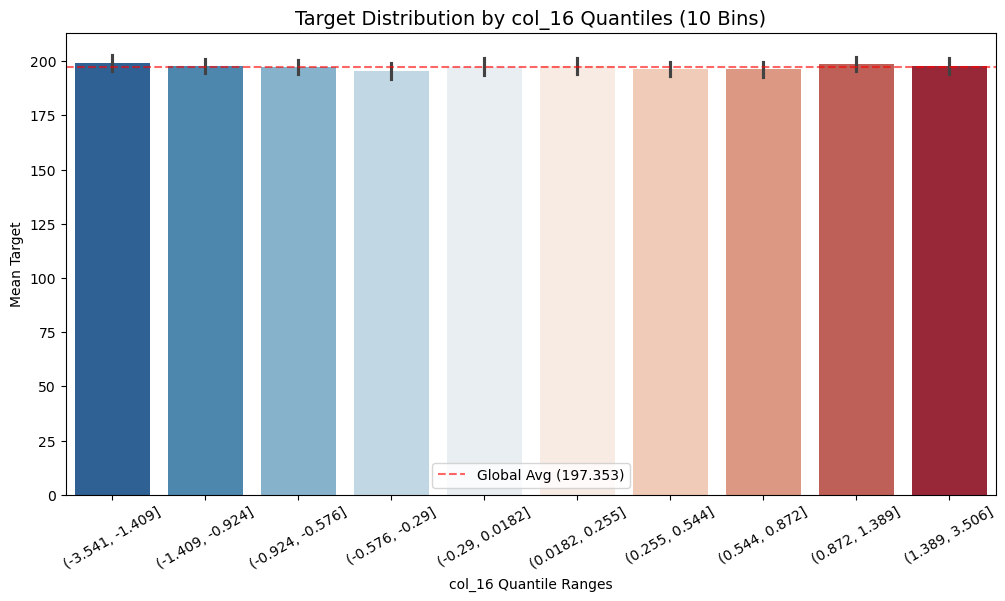

In [70]:
feature_analysis("col_16", 10)

,col_17_cut,target
0,"(-4.297000000000001, -1.381]",200.672011
1,"(-1.381, -0.857]",198.283744
2,"(-0.857, -0.531]",196.925219
3,"(-0.531, -0.252]",197.121854
4,"(-0.252, 0.00855]",201.541944
5,"(0.00855, 0.286]",196.243967
6,"(0.286, 0.565]",200.506052
7,"(0.565, 0.94]",197.926692
8,"(0.94, 1.436]",191.754754
9,"(1.436, 3.826]",192.544690


,mean,median,std,count,min,max,noise_ratio
col_17_cut,,,,,,,
"(-4.297000000000001, -1.381]",200.672011,197.197601,29.254023,200,134.517385,394.192258,0.145780
"(-1.381, -0.857]",198.283744,196.522969,26.841903,200,108.366523,290.140708,0.135371
"(-0.857, -0.531]",196.925219,195.817159,23.586254,200,107.483877,292.860631,0.119773
"(-0.531, -0.252]",197.121854,194.976058,24.661671,200,108.665528,277.500687,0.125109
"(-0.252, 0.00855]",201.541944,197.433992,30.129937,200,112.641142,400.000000,0.149497
"(0.00855, 0.286]",196.243967,195.383012,22.634151,199,120.659337,288.510777,0.115337
"(0.286, 0.565]",200.506052,197.582964,27.587986,200,116.293378,328.614535,0.137592
"(0.565, 0.94]",197.926692,195.749690,24.101625,200,124.639107,285.090376,0.121770
"(0.94, 1.436]",191.754754,194.191074,26.893958,200,80.000000,287.042407,0.140252


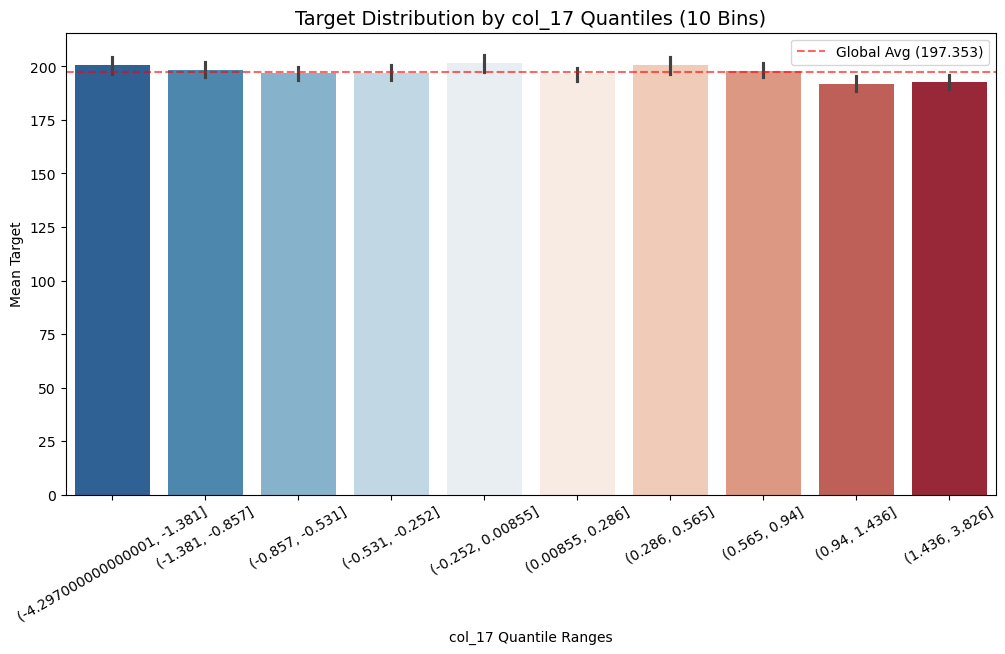

In [71]:
feature_analysis("col_17", 10)

,col_18_cut,target
0,"(-4.353000000000001, -1.34]",191.301064
1,"(-1.34, -0.856]",196.046432
2,"(-0.856, -0.554]",194.406741
3,"(-0.554, -0.254]",197.043306
4,"(-0.254, -0.0201]",198.500747
5,"(-0.0201, 0.24]",195.572320
6,"(0.24, 0.518]",199.929023
7,"(0.518, 0.884]",198.670340
8,"(0.884, 1.377]",197.017637
9,"(1.377, 3.561]",205.029957


,mean,median,std,count,min,max,noise_ratio
col_18_cut,,,,,,,
"(-4.353000000000001, -1.34]",191.301064,193.745354,30.540224,200,87.691504,394.192258,0.159645
"(-1.34, -0.856]",196.046432,195.437772,22.624314,200,80.000000,268.617677,0.115403
"(-0.856, -0.554]",194.406741,193.831728,24.522572,200,112.641142,291.436374,0.126141
"(-0.554, -0.254]",197.043306,195.324787,20.660835,200,122.163522,266.363668,0.104854
"(-0.254, -0.0201]",198.500747,195.515500,22.403083,200,115.777105,287.042407,0.112861
"(-0.0201, 0.24]",195.572320,194.526746,22.222891,199,114.736771,292.860631,0.113630
"(0.24, 0.518]",199.929023,196.552865,27.059493,200,123.608019,298.702722,0.135345
"(0.518, 0.884]",198.670340,196.961517,21.868660,200,120.154795,272.913214,0.110075
"(0.884, 1.377]",197.017637,195.684277,28.019232,200,108.366523,273.428468,0.142217


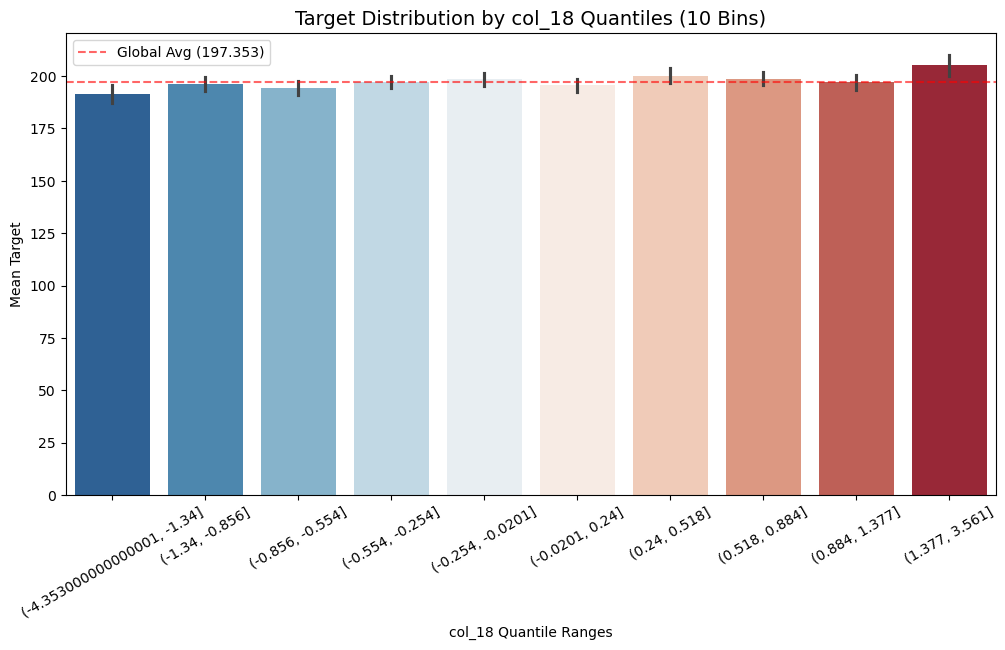

In [72]:
feature_analysis("col_18", 10)

,col_19_cut,target
0,"(-3.274, -1.338]",194.021622
1,"(-1.338, -0.877]",197.013890
2,"(-0.877, -0.562]",198.593511
3,"(-0.562, -0.274]",196.481633
4,"(-0.274, -0.0273]",196.104198
5,"(-0.0273, 0.272]",197.114642
6,"(0.272, 0.573]",198.469604
7,"(0.573, 0.942]",198.184949
8,"(0.942, 1.356]",197.586024
9,"(1.356, 3.699]",199.955208


,mean,median,std,count,min,max,noise_ratio
col_19_cut,,,,,,,
"(-3.274, -1.338]",194.021622,194.471920,23.126554,200,108.665528,269.258083,0.119196
"(-1.338, -0.877]",197.013890,194.785168,23.653414,200,119.569057,292.860631,0.120060
"(-0.877, -0.562]",198.593511,197.547268,24.541003,200,105.263432,290.140708,0.123574
"(-0.562, -0.274]",196.481633,196.187722,20.328952,200,116.253370,276.022298,0.103465
"(-0.274, -0.0273]",196.104198,195.222884,26.058604,200,116.866950,277.500687,0.132881
"(-0.0273, 0.272]",197.114642,195.785795,28.547917,199,87.691504,349.973208,0.144829
"(0.272, 0.573]",198.469604,195.098554,26.158808,200,120.154795,288.510777,0.131803
"(0.573, 0.942]",198.184949,195.738729,22.570703,200,135.764737,287.042407,0.113887
"(0.942, 1.356]",197.586024,197.066983,32.743990,200,112.641142,394.192258,0.165720


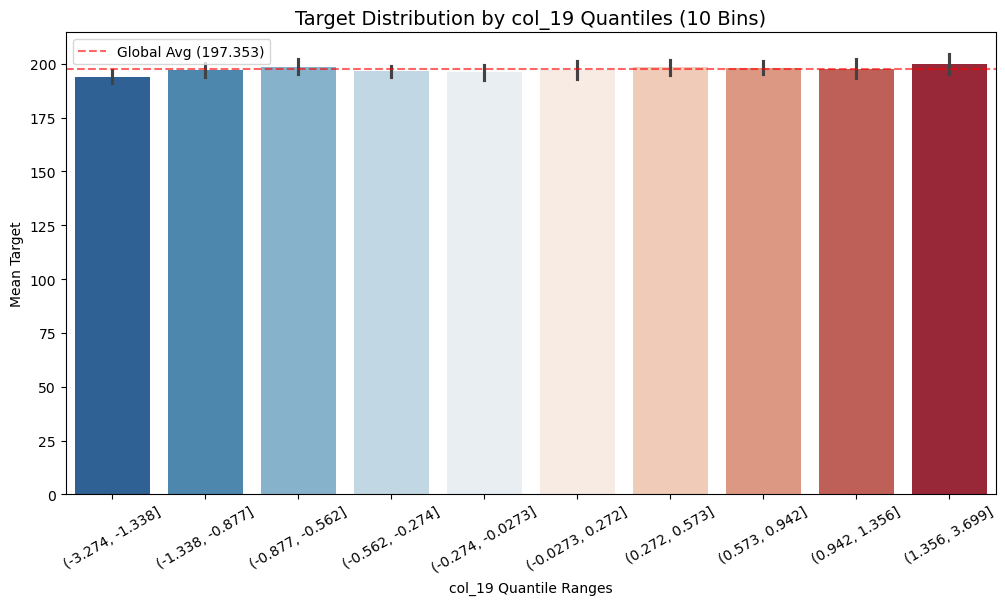

In [73]:
feature_analysis("col_19", 10)

,col_20_cut,target
0,"(-3.343, -1.372]",198.791706
1,"(-1.372, -0.89]",197.505815
2,"(-0.89, -0.558]",196.775707
3,"(-0.558, -0.294]",196.699538
4,"(-0.294, -0.0376]",199.440362
5,"(-0.0376, 0.247]",199.752570
6,"(0.247, 0.523]",195.016787
7,"(0.523, 0.883]",197.307229
8,"(0.883, 1.356]",195.846918
9,"(1.356, 3.287]",196.401839


,mean,median,std,count,min,max,noise_ratio
col_20_cut,,,,,,,
"(-3.343, -1.372]",198.791706,196.659434,25.506996,200,106.201614,288.510777,0.128310
"(-1.372, -0.89]",197.505815,196.714083,23.598483,200,114.736771,281.946756,0.119482
"(-0.89, -0.558]",196.775707,196.800435,26.469629,200,112.641142,291.436374,0.134517
"(-0.558, -0.294]",196.699538,196.482211,26.613396,200,80.000000,298.702722,0.135300
"(-0.294, -0.0376]",199.440362,196.126063,27.172812,200,125.013425,394.192258,0.136245
"(-0.0376, 0.247]",199.752570,195.166200,27.775381,199,120.659337,400.000000,0.139049
"(0.247, 0.523]",195.016787,194.247524,26.500904,200,107.483877,286.771919,0.135890
"(0.523, 0.883]",197.307229,195.173320,23.856652,200,105.263432,292.416417,0.120911
"(0.883, 1.356]",195.846918,195.381747,24.268013,200,110.857473,328.614535,0.123913


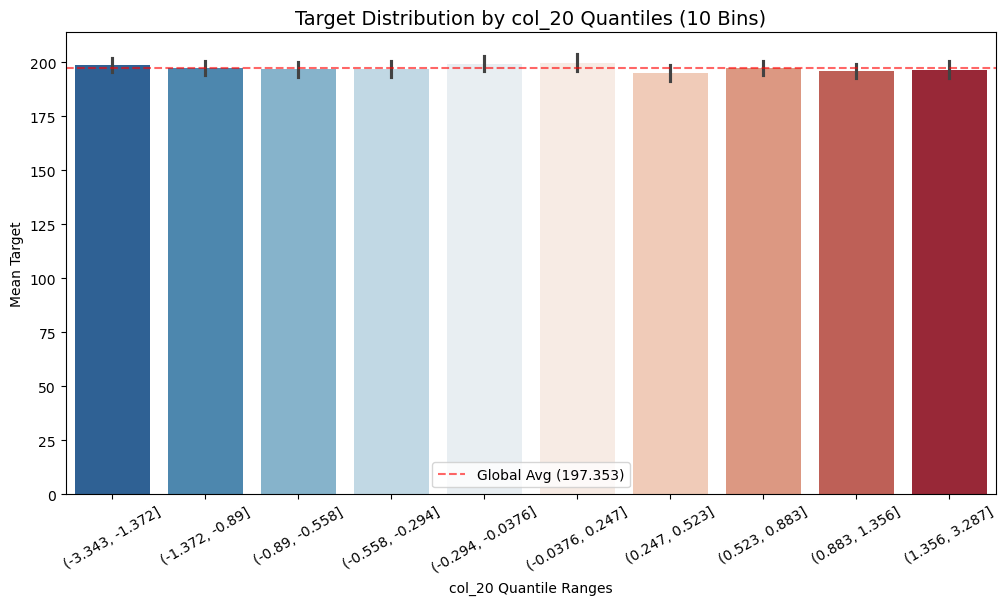

In [74]:
feature_analysis("col_20", 10)

,col_20_cut,target
0,"(-3.343, -1.234]",198.941586
1,"(-1.234, -0.719]",196.961483
2,"(-0.719, -0.373]",197.568985
3,"(-0.373, -0.0376]",197.898448
4,"(-0.0376, 0.316]",199.037196
5,"(0.316, 0.704]",195.652636
6,"(0.704, 1.223]",196.076625
7,"(1.223, 3.287]",196.690956


,mean,median,std,count,min,max,noise_ratio
col_20_cut,,,,,,,
"(-3.343, -1.234]",198.941586,196.522731,25.053731,250,106.201614,288.510777,0.125935
"(-1.234, -0.719]",196.961483,196.975606,25.179223,250,114.736771,291.436374,0.127838
"(-0.719, -0.373]",197.568985,196.809340,27.087755,250,80.000000,298.702722,0.137105
"(-0.373, -0.0376]",197.898448,195.967705,26.238359,250,108.665528,394.192258,0.132585
"(-0.0376, 0.316]",199.037196,194.931314,27.442776,249,107.483877,400.000000,0.137878
"(0.316, 0.704]",195.652636,195.126900,23.526216,250,108.366523,278.155918,0.120245
"(0.704, 1.223]",196.076625,195.059322,25.466692,250,105.263432,292.416417,0.129881
"(1.223, 3.287]",196.690956,195.588960,30.151930,250,87.691504,349.973208,0.153296


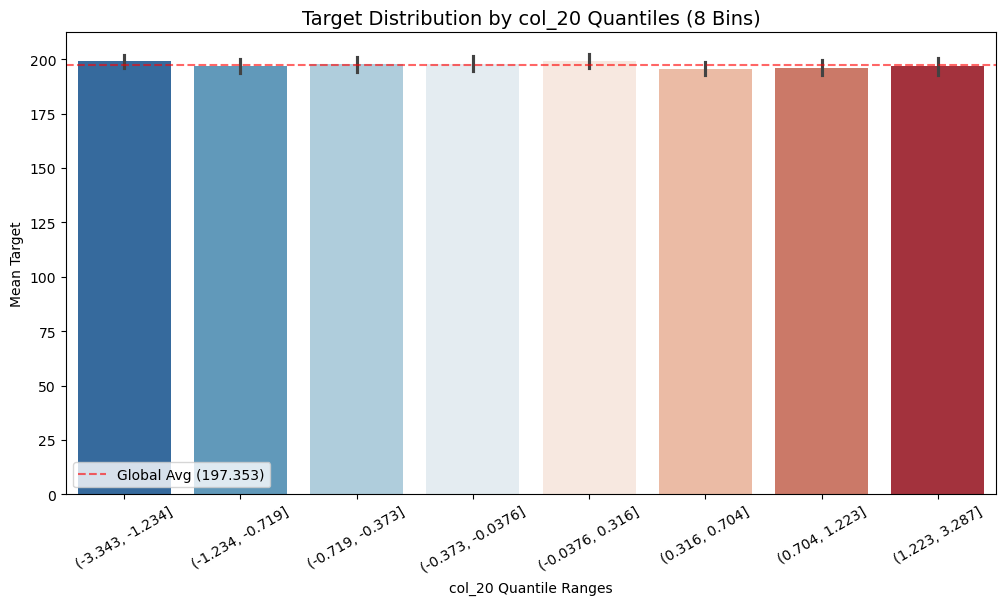

In [76]:
feature_analysis("col_20", 8)

,col_21_cut,target
0,"(-5.179, -1.318]",191.718449
1,"(-1.318, -0.843]",195.295782
2,"(-0.843, -0.52]",197.719272
3,"(-0.52, -0.276]",194.572048
4,"(-0.276, 0.00945]",196.869281
5,"(0.00945, 0.271]",196.800241
6,"(0.271, 0.564]",195.529428
7,"(0.564, 0.891]",199.150061
8,"(0.891, 1.364]",201.194417
9,"(1.364, 3.88]",204.674728


,mean,median,std,count,min,max,noise_ratio
col_21_cut,,,,,,,
"(-5.179, -1.318]",191.718449,193.856939,27.160482,200,80.000000,269.258083,0.141669
"(-1.318, -0.843]",195.295782,194.408372,26.832356,200,106.201614,394.192258,0.137393
"(-0.843, -0.52]",197.719272,196.125256,21.718051,200,131.361387,298.702722,0.109843
"(-0.52, -0.276]",194.572048,194.087800,18.882252,200,114.736771,261.368534,0.097045
"(-0.276, 0.00945]",196.869281,194.553691,23.445502,200,122.163522,290.140708,0.119092
"(0.00945, 0.271]",196.800241,195.833931,23.819462,199,115.777105,286.771919,0.121034
"(0.271, 0.564]",195.529428,194.418078,27.885704,200,110.494596,292.860631,0.142616
"(0.564, 0.891]",199.150061,197.306823,25.423846,200,119.569057,280.348135,0.127662
"(0.891, 1.364]",201.194417,197.968182,27.646660,200,116.293378,286.592472,0.137413


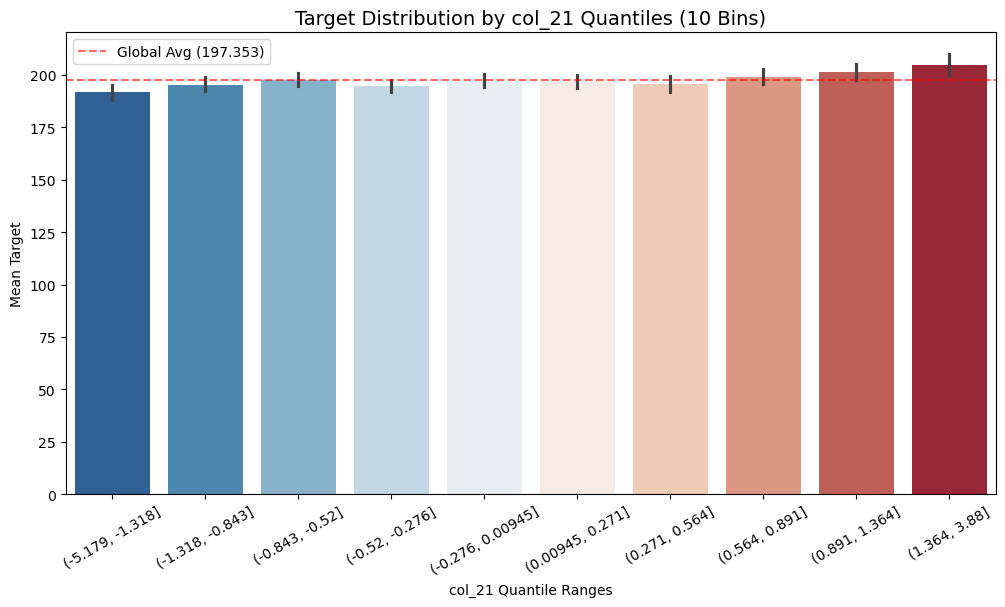

In [77]:
feature_analysis("col_21", 10)

,col_22_cut,target
0,"(-3.895, -1.358]",200.723786
1,"(-1.358, -0.917]",196.949829
2,"(-0.917, -0.571]",198.967128
3,"(-0.571, -0.284]",199.857679
4,"(-0.284, -0.0221]",197.116902
5,"(-0.0221, 0.246]",199.627659
6,"(0.246, 0.547]",193.227083
7,"(0.547, 0.899]",200.201870
8,"(0.899, 1.409]",193.481148
9,"(1.409, 3.694]",193.384760


,mean,median,std,count,min,max,noise_ratio
col_22_cut,,,,,,,
"(-3.895, -1.358]",200.723786,197.302730,26.657764,200,134.517385,394.192258,0.132808
"(-1.358, -0.917]",196.949829,195.632990,25.899868,200,116.866950,286.592472,0.131505
"(-0.917, -0.571]",198.967128,197.127866,26.707641,200,110.494596,298.702722,0.134231
"(-0.571, -0.284]",199.857679,198.772426,26.947053,200,108.366523,288.510777,0.134831
"(-0.284, -0.0221]",197.116902,195.173776,23.657306,200,112.734726,273.747141,0.120017
"(-0.0221, 0.246]",199.627659,196.760294,24.242907,199,116.293378,349.973208,0.121441
"(0.246, 0.547]",193.227083,194.385938,28.973723,200,80.000000,290.140708,0.149946
"(0.547, 0.899]",200.201870,196.817411,27.724623,200,114.736771,400.000000,0.138483
"(0.899, 1.409]",193.481148,192.985522,27.016545,200,105.263432,328.614535,0.139634


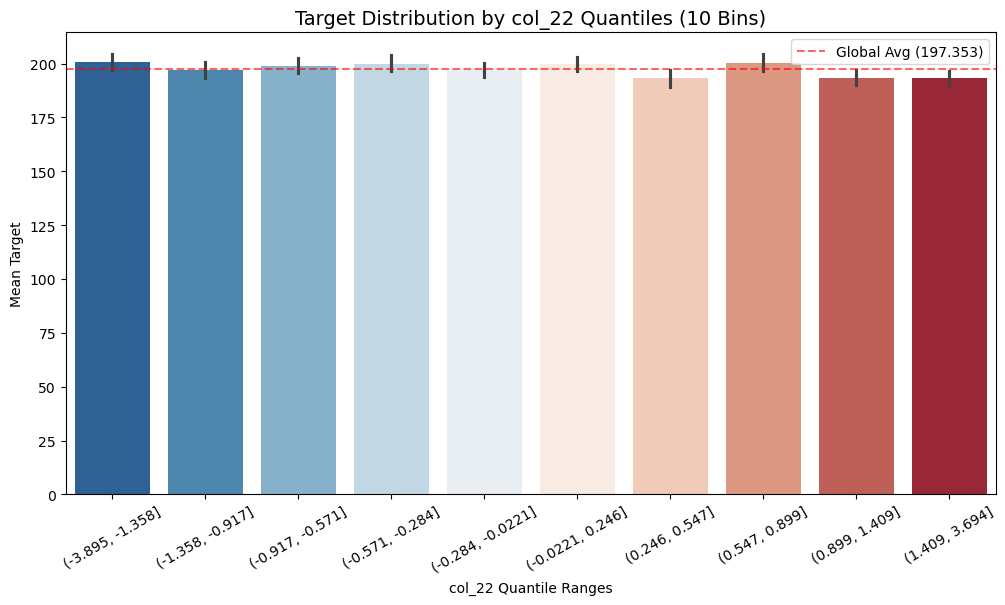

In [78]:
feature_analysis("col_22", 10)

,col_23_cut,target
0,"(-3.778, -1.339]",196.250191
1,"(-1.339, -0.897]",196.445969
2,"(-0.897, -0.569]",196.054097
3,"(-0.569, -0.29]",196.844998
4,"(-0.29, 0.00948]",196.689276
5,"(0.00948, 0.283]",196.460278
6,"(0.283, 0.577]",199.169619
7,"(0.577, 0.886]",198.973728
8,"(0.886, 1.393]",196.847686
9,"(1.393, 3.803]",199.786164


,mean,median,std,count,min,max,noise_ratio
col_23_cut,,,,,,,
"(-3.778, -1.339]",196.250191,194.803409,21.250915,200,108.665528,281.946756,0.108285
"(-1.339, -0.897]",196.445969,196.105401,24.438145,200,110.494596,292.860631,0.124401
"(-0.897, -0.569]",196.054097,195.524647,22.342995,200,105.263432,266.564527,0.113963
"(-0.569, -0.29]",196.844998,195.419627,24.947982,200,116.253370,290.140708,0.126739
"(-0.29, 0.00948]",196.689276,195.298703,23.973748,200,110.857473,280.140598,0.121886
"(0.00948, 0.283]",196.460278,195.696515,31.081656,199,87.691504,349.973208,0.158208
"(0.283, 0.577]",199.169619,195.864415,23.085864,200,143.088158,273.747141,0.115911
"(0.577, 0.886]",198.973728,198.520346,25.140453,200,106.201614,286.592472,0.126351
"(0.886, 1.393]",196.847686,196.230649,31.493759,200,112.641142,400.000000,0.159990


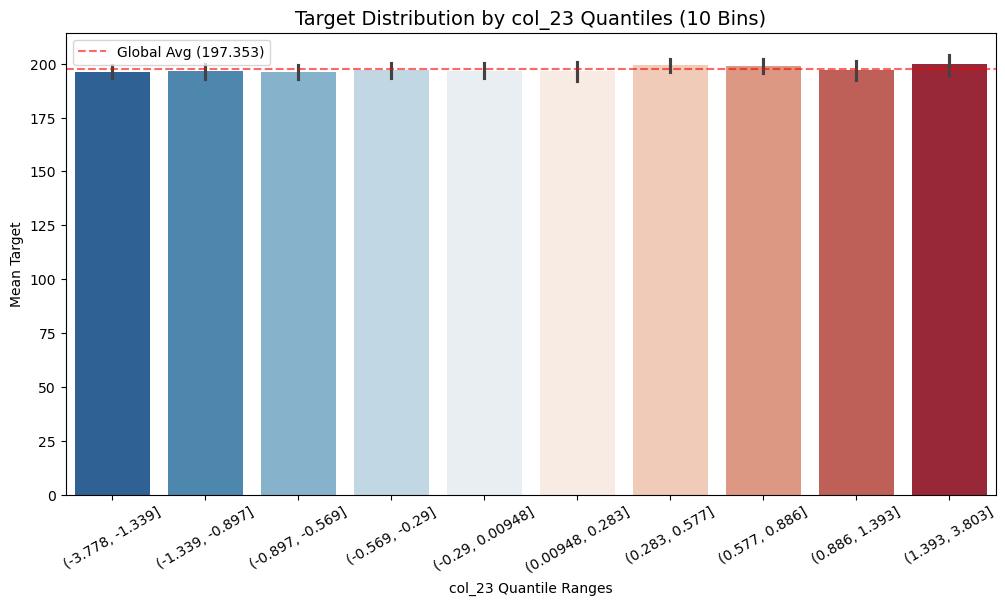

In [79]:
feature_analysis("col_23", 10)

,col_24_cut,target
0,"(-3.25, -1.285]",197.200376
1,"(-1.285, -0.848]",198.974291
2,"(-0.848, -0.519]",193.106037
3,"(-0.519, -0.243]",199.584640
4,"(-0.243, 0.029]",196.728346
5,"(0.029, 0.259]",200.953720
6,"(0.259, 0.537]",197.977292
7,"(0.537, 0.925]",196.922448
8,"(0.925, 1.364]",197.373583
9,"(1.364, 4.25]",194.723742


,mean,median,std,count,min,max,noise_ratio
col_24_cut,,,,,,,
"(-3.25, -1.285]",197.200376,195.527571,25.137955,200,107.483877,285.090376,0.127474
"(-1.285, -0.848]",198.974291,196.786313,25.082142,200,108.366523,277.314646,0.126057
"(-0.848, -0.519]",193.106037,193.755377,28.436215,200,105.263432,298.702722,0.147257
"(-0.519, -0.243]",199.584640,196.645253,26.445142,200,108.665528,290.140708,0.132501
"(-0.243, 0.029]",196.728346,194.472719,24.906282,200,115.777105,328.614535,0.126602
"(0.029, 0.259]",200.953720,198.035022,27.613793,199,119.573770,394.192258,0.137414
"(0.259, 0.537]",197.977292,196.817411,24.216462,200,131.985981,286.592472,0.122319
"(0.537, 0.925]",196.922448,195.363277,24.691685,200,116.253370,292.860631,0.125388
"(0.925, 1.364]",197.373583,194.585936,31.689927,200,80.000000,400.000000,0.160558


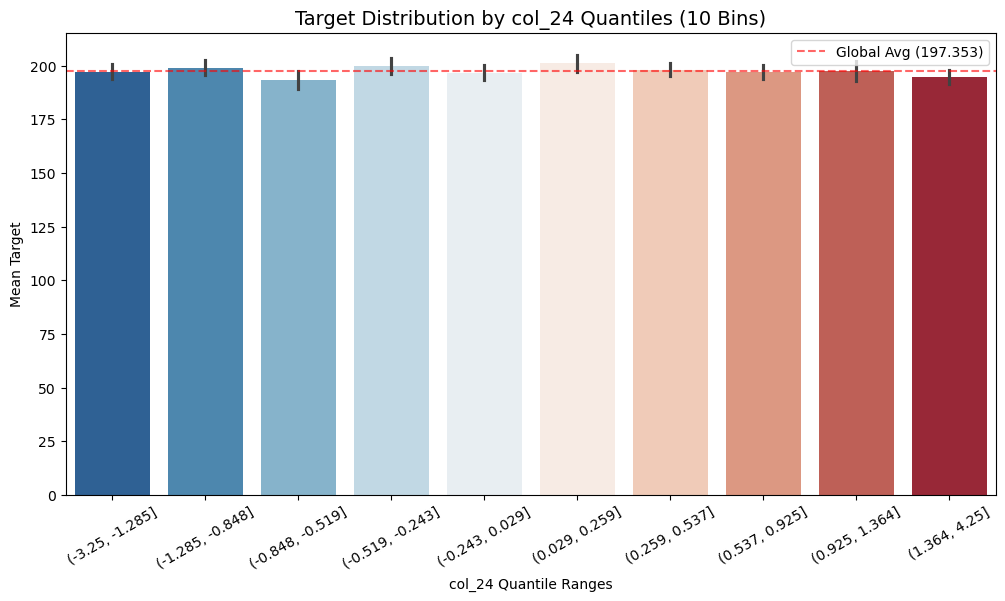

In [80]:
feature_analysis("col_24", 10)

In [97]:
from itertools import combinations

# Define the clusters identified from the heatmap
clusters = {
    "Series A (Odd)": ["col_1", "col_19", "col_23"],
    "Series B (Even)": ["col_2", "col_9", "col_18", "col_21"],
    "Cluster 3": ["col_3", "col_10", "col_20"],
    "Cluster 4": ["col_5", "col_11", "col_17", "col_22"],
    "Cluster 5 (Large)": ["col_7", "col_13", "col_14", "col_15", "col_16"],
    "Cluster 6": ["col_8", "col_12"],
    "Cluster 7": ["col_6", "col_24"]
}

def evaluate_cluster_features(df, cluster_name, features, target='target'):
    results = []
    
    # 1. Evaluate Raw Features
    for feat in features:
        corr = df[feat].corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': feat, 'Type': 'Raw', 'Correlation': corr})
        
    # 2. Evaluate Combination (Sum/Mean)
    # Summing reduces noise if the features are similar measurements
    combined_sum = df[features].sum(axis=1)
    corr_sum = combined_sum.corr(df[target])
    results.append({'Cluster': cluster_name, 'Feature': f"Sum({len(features)} feats)", 'Type': 'Combination (a+b)', 'Correlation': corr_sum})
    
    # 3. Evaluate Differences (Pairwise)
    # This captures the 'divergence' between highly correlated features
    for a, b in combinations(features, 2):
        diff_feat = df[a] - df[b]
        corr_diff = diff_feat.corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': f"{a} - {b}", 'Type': 'Difference', 'Correlation': corr_diff})
        
    # 4. Evaluate Interaction (Pairwise Product)
    for a, b in combinations(features, 2):
        inter_feat = df[a] * df[b]
        corr_inter = inter_feat.corr(df[target])
        results.append({'Cluster': cluster_name, 'Feature': f"{a} * {b}", 'Type': 'Interaction', 'Correlation': corr_inter})
        
    return pd.DataFrame(results)

# Run evaluation for all clusters
all_results = []
for name, cols in clusters.items():
    all_results.append(evaluate_cluster_features(df, name, cols))

# Combine and sort by absolute correlation strength
summary_df = pd.concat(all_results)
summary_df['Abs_Corr'] = summary_df['Correlation'].abs()
summary_df = summary_df.sort_values(by=['Cluster', 'Abs_Corr'], ascending=[True, False])

# Show top performing feature for each cluster
best_per_cluster = summary_df.groupby('Cluster').head(1)
print("--- Best Performing Feature Transformation per Cluster ---")
print(best_per_cluster[['Cluster', 'Feature', 'Type', 'Correlation']])

# To see the full comparison:
# print(summary_df)

--- Best Performing Feature Transformation per Cluster ---
              Cluster          Feature         Type  Correlation
0           Cluster 3            col_3          Raw    -0.035802
2           Cluster 4           col_17          Raw    -0.081342
25  Cluster 5 (Large)  col_15 * col_16  Interaction    -0.044021
3           Cluster 6   col_8 - col_12   Difference     0.030169
0           Cluster 7            col_6          Raw    -0.016204
0      Series A (Odd)            col_1          Raw     0.043973
0     Series B (Even)            col_2          Raw     0.131074


In [93]:
# Create the final refined dataframe
df_final = df.copy()

# 1. Handle Clusters where RAW was best (Keep best, drop others)
# Series B: Keep col_2, Drop [9, 18, 21]
df_final = df_final.drop(columns=['col_9', 'col_18', 'col_21'])

# Series A: Keep col_1, Drop [19, 23]
df_final = df_final.drop(columns=['col_19', 'col_23'])

# Cluster 3: Keep col_3, Drop [10, 20]
df_final = df_final.drop(columns=['col_10', 'col_20'])

# Cluster 4: Keep col_17, Drop [5, 11, 22]
df_final = df_final.drop(columns=['col_5', 'col_11', 'col_22'])

# Cluster 7: Keep col_6, Drop [col_24]
df_final = df_final.drop(columns=['col_24'])


# 2. Handle Interaction Cluster (Cluster 5)
df_final['feat_15_16_interaction'] = df['col_15'] * df['col_16']
df_final = df_final.drop(columns=['col_7', 'col_13', 'col_14', 'col_15', 'col_16'])


# 3. Handle Difference Cluster (Cluster 6)
df_final['feat_8_12_diff'] = df['col_8'] - df['col_12']
df_final = df_final.drop(columns=['col_8', 'col_12'])

print(f"Original feature count: {len(df.columns)}")
print(f"Refined feature count: {len(df_final.columns)}")

Original feature count: 54
Refined feature count: 38


In [95]:
df_final['target'] = df['target']

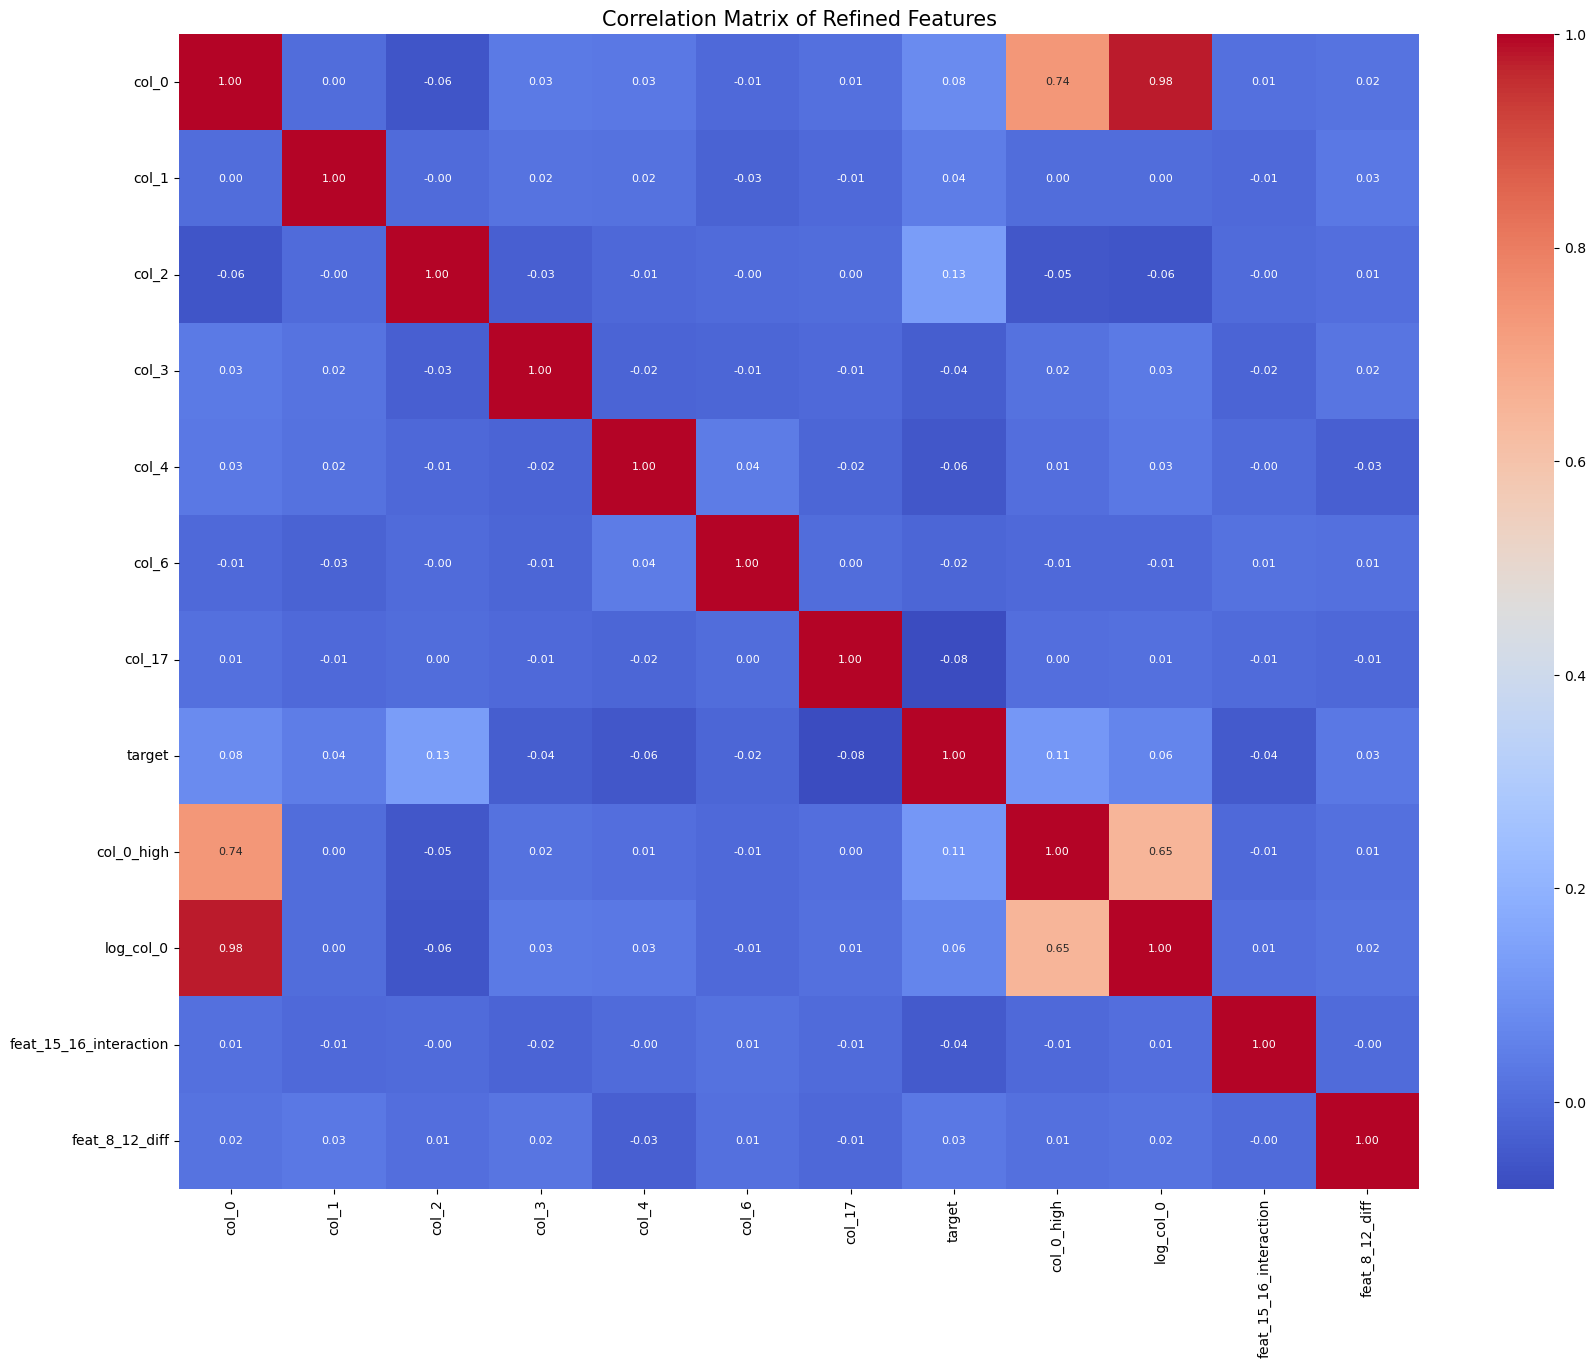

In [96]:

plt.figure(figsize=(20, 15))


corr_matrix = df_final.corr(numeric_only=True)

sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap='coolwarm', 
            annot_kws={"size": 8})

plt.title("Correlation Matrix of Refined Features", fontsize=15)
plt.show()